# IPCC — Análisis de Trayectorias Temporales 2015–2023
## EE.UU. · Alemania · España · Francia · 52 regiones

| Celda | Contenido | Figuras |
|-------|-----------|---------|
| 1 | Configuración | — |
| 2 | Descarga Eurostat + BEA → `df_traj` | `trayectorias_ccpi.csv` |
| 3 | **4 figuras separadas por país** | `F_tray_DE/ES/FR/EEUU_detalle.png` |
| 4 | Figura combinada flechas 2015→2023 | `F4_trayectorias_combinado.png` |
| 5 | Resumen mayor movimiento | — |

**Eje X:** IPCC Método 3 · **Eje Y:** PIB pc real (EUR PPS para Europa, USD para EE.UU.)


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 1 — CONFIGURACIÓN GENERAL
# ══════════════════════════════════════════════════════════════════════════════
%matplotlib inline
import warnings, os, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from IPython.display import display
import eurostat

warnings.filterwarnings('ignore')

BASE_FIGURAS = '/Users/diego/Desktop/MT/prototipo_ccpi/figures'
BASE_DATA    = '/Users/diego/Desktop/MT/Code/data'
os.makedirs(BASE_FIGURAS, exist_ok=True)

# ── Paletas visuales ──────────────────────────────────────────────────────────
COLOR_TIER  = {1: '#8B1A1A', 2: '#E07B39', 3: '#A9A9A9'}
MARKER_TIER = {1: '*',       2: 'D',       3: 'o'}
SIZE_TIER   = {1: 280,       2: 160,       3: 90}
COLOR_PAIS  = {'EEUU': '#1A3A6B', 'DE': '#2D6A2D', 'ES': '#8B1A1A', 'FR': '#5C2D8B'}

AÑOS        = [2015, 2018, 2021, 2023]
S_AÑO       = {2015: 30,  2018: 55,  2021: 80,  2023: 130}
ALPHA_AÑO   = {2015: 0.3, 2018: 0.5, 2021: 0.7, 2023: 1.0}

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Serif', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.color': '#E8E0D8', 'grid.linewidth': 0.55,
})

# ── Regiones por país (idéntico a notebooks de país) ─────────────────────────
NUTS2_DE = {
    'DE21': ('Oberbayern',  1), 'DE30': ('Berlin',      1), 'DE60': ('Hamburg',     1),
    'DE11': ('Stuttgart',   2), 'DE12': ('Karlsruhe',   2), 'DE71': ('Darmstadt',   2),
    'DEA1': ('Düsseldorf',  2), 'DEA2': ('Köln',        2),
    'DED2': ('Dresden',     3), 'DED5': ('Leipzig',     3), 'DEG0': ('Thüringen',   3),
    'DE94': ('Weser-Ems',   3), 'DE13': ('Freiburg',    3),
}
NUTS2_ES = {
    'ES30': ('Madrid',          1), 'ES51': ('Cataluña',        1), 'ES61': ('Andalucía',       1),
    'ES52': ('C. Valenciana',   2), 'ES21': ('País Vasco',      2), 'ES11': ('Galicia',         2),
    'ES41': ('Castilla y León', 2), 'ES70': ('Canarias',        2),
    'ES24': ('Aragón',          3), 'ES12': ('Asturias',        3), 'ES62': ('Murcia',          3),
    'ES22': ('Navarra',         3), 'ES13': ('Cantabria',       3),
}
NUTS2_FR = {
    'FR10': ('Île-de-France',    1), 'FRK2': ('Rhône-Alpes',      1), 'FRL0': ('PACA',             1),
    'FRJ2': ('Midi-Pyrénées',    2), 'FRI3': ('Gironde-Aquit.',   2), 'FRE1': ('Nord-Pas-Calais',  2),
    'FRF3': ('Lorraine',         2), 'FRG0': ('Pays de la Loire', 2),
    'FRH0': ('Bretagne',         3), 'FRD1': ('Basse-Normandie',  3), 'FRC1': ('Bourgogne',        3),
    'FRB0': ('Centre-Val Loire', 3), 'FRM0': ('Corse',            3),
}
MSAS_EEUU = {
    '35620': ('Nueva York',    1), '31080': ('Los Ángeles',   1), '16980': ('Chicago',       1),
    '26420': ('Houston',       2), '19100': ('Dallas',        2), '37980': ('Filadelfia',    2),
    '33100': ('Miami',         2), '12060': ('Atlanta',       2),
    '38300': ('Pittsburgh',    3), '17460': ('Cleveland',     3), '32820': ('Memphis',       3),
    '15380': ('Buffalo',       3), '35380': ('Nueva Orleans', 3),
}

# ── Goalposts fijos ──────────────────────────────────────────────────────────
GOALPOSTS_DE = {
    'gdp_pc':   (15_000, 60_000), 'tcac_pc':  (0.00, 0.06),
    'vab_pc':   (10_000, 55_000), 'densidad': (20, 80),
    'lq_vab':   (0.20, 3.00),     'lq_den':   (0.20, 3.00),
    'tasa_ocup':(0.65, 0.85),     'tasa_des': (0.02, 0.12),
    'pct_form': (0.80, 0.95),     'pct_cal':  (0.30, 0.70),
    'brecha':   (0.00, 0.50),     'cap_sub':  (0.00, 0.15),
    'clase_m':  (0.00, 0.35),     'pct_terc': (0.20, 0.60),
    'esc_prom': (11.0, 17.0),
}
GOALPOSTS_ESFR = {
    'gdp_pc':   (14_000, 68_000), 'tcac_pc':  (-0.005, 0.045),
    'emp_rate': (52.0, 80.0),     'unemp_r':  (3.0, 25.0),
    'pct_form': (0.72, 0.94),     'pct_cal':  (0.27, 0.58),
    'brecha':   (-0.60, 0.40),    'conv_pc':  (-0.025, 0.025),
    'pct_terc': (30.0, 70.0),
}
GOALPOSTS_US = {
    'gdp_pc':   (25_000, 120_000), 'tcac_pc':  (0.00, 0.08),
    'densidad': (15, 80),          'lq_gdp':   (0.20, 3.00),
    'lq_den':   (0.20, 3.00),     'tasa_ocup':(0.45, 0.70),
    'tasa_des': (0.02, 0.15),     'pct_form': (0.50, 0.90),
    'pct_cal':  (0.15, 0.65),     'brecha':   (0.00, 0.60),
    'cap_sub':  (0.00, 0.10),     'clase_m':  (0.20, 0.50),
    'pct_terc': (0.15, 0.65),     'esc_prom': (10.0, 17.0),
}

BEA_KEY    = '1C156F46-4433-4B50-995A-193FD1446E22'
CENSUS_KEY = '521bd10f68ec050e57f22908aca90c66eb43488c'

def gp(valor, mn, mx, inv=False):
    # Normalización goalpost [0,1]. inv=True invierte la escala.
    try:
        if valor is None or np.isnan(float(valor)):
            return 0.5
        s = (mx - float(valor)) / (mx - mn) if inv else (float(valor) - mn) / (mx - mn)
        return float(np.clip(s, 0.0, 1.0))
    except (TypeError, ValueError):
        return 0.5

def tcac(v0, v1, n):
    # TCAC anualizado entre v0 y v1 en n años.
    if v0 is None or v1 is None or v0 <= 0 or v1 <= 0 or n <= 0:
        return 0.0
    return float((v1 / v0) ** (1 / n) - 1)

def eu_val(df, geo, yr, fallback=None):
    # Valor Eurostat para geo y año; busca año más cercano si hay NaN.
    # Maneja índices duplicados tomando el primer valor escalar.
    col = str(yr)
    if geo not in df.index:
        return fallback
    def _scalar(val):
        # Si es Serie (índice duplicado), toma el primer elemento
        if isinstance(val, pd.Series):
            val = val.dropna()
            return float(val.iloc[0]) if len(val) > 0 else np.nan
        return float(val) if not pd.isna(val) else np.nan
    raw = df.loc[geo, col] if col in df.columns else np.nan
    v   = _scalar(raw)
    if np.isnan(v):
        for dy in [1, 2, -1, -2, 3, -3]:
            col2 = str(yr + dy)
            if col2 in df.columns:
                v2 = _scalar(df.loc[geo, col2])
                if not np.isnan(v2):
                    return v2
        return fallback
    return v


# ── Datos BLS LAUS por MSA y año (tasas anuales promedio) ───────────────────
# Fuente: BLS Local Area Unemployment Statistics (LAUS) — valores aproximados
LAUS_UNEMP = {   # Tasa desempleo anual (%) — BLS LAUS
    '35620': {2015: 5.4, 2018: 3.9, 2021: 9.9, 2023: 4.6},  # Nueva York
    '31080': {2015: 6.9, 2018: 4.0, 2021:11.0, 2023: 5.1},  # Los Ángeles
    '16980': {2015: 6.1, 2018: 4.1, 2021: 9.4, 2023: 4.3},  # Chicago
    '26420': {2015: 4.8, 2018: 3.8, 2021: 8.0, 2023: 4.0},  # Houston
    '19100': {2015: 3.8, 2018: 3.2, 2021: 6.0, 2023: 3.5},  # Dallas
    '37980': {2015: 5.6, 2018: 4.1, 2021: 9.5, 2023: 3.9},  # Filadelfia
    '33100': {2015: 5.8, 2018: 3.3, 2021: 8.5, 2023: 3.2},  # Miami
    '12060': {2015: 5.5, 2018: 3.6, 2021: 6.5, 2023: 3.4},  # Atlanta
    '38300': {2015: 5.0, 2018: 3.8, 2021: 6.7, 2023: 3.7},  # Pittsburgh
    '17460': {2015: 5.3, 2018: 4.1, 2021: 8.5, 2023: 4.5},  # Cleveland
    '32820': {2015: 5.7, 2018: 4.1, 2021: 7.5, 2023: 4.4},  # Memphis
    '15380': {2015: 5.5, 2018: 4.0, 2021: 8.3, 2023: 3.9},  # Buffalo
    '35380': {2015: 5.5, 2018: 3.8, 2021: 8.0, 2023: 3.6},  # Nueva Orleans
}
EMP_RATE_US = {  # Tasa empleo anual (emp/pop16+, %) — BLS/ACS aproximado
    '35620': {2015: 54.5, 2018: 57.5, 2021: 52.8, 2023: 56.5},  # Nueva York
    '31080': {2015: 55.8, 2018: 58.2, 2021: 52.5, 2023: 56.2},  # Los Ángeles
    '16980': {2015: 54.8, 2018: 57.2, 2021: 53.0, 2023: 56.0},  # Chicago
    '26420': {2015: 60.0, 2018: 62.0, 2021: 58.0, 2023: 61.5},  # Houston
    '19100': {2015: 62.5, 2018: 65.0, 2021: 61.5, 2023: 64.0},  # Dallas
    '37980': {2015: 55.5, 2018: 58.0, 2021: 53.5, 2023: 57.0},  # Filadelfia
    '33100': {2015: 55.5, 2018: 58.5, 2021: 54.0, 2023: 57.5},  # Miami
    '12060': {2015: 59.0, 2018: 61.5, 2021: 59.5, 2023: 62.5},  # Atlanta
    '38300': {2015: 53.5, 2018: 56.0, 2021: 53.5, 2023: 56.0},  # Pittsburgh
    '17460': {2015: 52.0, 2018: 54.0, 2021: 50.5, 2023: 53.5},  # Cleveland
    '32820': {2015: 53.0, 2018: 54.5, 2021: 51.5, 2023: 54.0},  # Memphis
    '15380': {2015: 51.5, 2018: 53.5, 2021: 51.0, 2023: 53.0},  # Buffalo
    '35380': {2015: 53.5, 2018: 56.0, 2021: 52.5, 2023: 55.0},  # Nueva Orleans
}

# ── Poverty rate % por MSA y año — Census SAIPE ──────────────────────────────
# (usado para cap_sub: poverty_rate/200 → escala [0,0.10] del goalpost)
SAIPE_POV_US = {
    '35620': {2015: 14.5, 2018: 13.2, 2021: 12.8, 2023: 11.8},  # Nueva York
    '31080': {2015: 16.0, 2018: 14.5, 2021: 14.2, 2023: 13.0},  # Los Ángeles
    '16980': {2015: 13.5, 2018: 11.8, 2021: 11.5, 2023: 10.5},  # Chicago
    '26420': {2015: 16.0, 2018: 14.5, 2021: 14.0, 2023: 13.0},  # Houston
    '19100': {2015: 13.5, 2018: 11.5, 2021: 11.0, 2023: 10.0},  # Dallas
    '37980': {2015: 13.0, 2018: 11.5, 2021: 11.0, 2023: 10.0},  # Filadelfia
    '33100': {2015: 16.5, 2018: 15.0, 2021: 15.5, 2023: 14.0},  # Miami
    '12060': {2015: 14.5, 2018: 12.5, 2021: 12.0, 2023: 11.0},  # Atlanta
    '38300': {2015: 11.5, 2018: 10.5, 2021: 10.0, 2023:  9.5},  # Pittsburgh
    '17460': {2015: 16.5, 2018: 15.0, 2021: 14.5, 2023: 13.5},  # Cleveland
    '32820': {2015: 19.0, 2018: 18.0, 2021: 17.5, 2023: 16.5},  # Memphis
    '15380': {2015: 16.5, 2018: 15.0, 2021: 14.5, 2023: 13.5},  # Buffalo
    '35380': {2015: 18.5, 2018: 17.0, 2021: 16.5, 2023: 15.5},  # Nueva Orleans
}

# ── % hogares con ingreso $35K–$100K por MSA y año — ACS B19001 ──────────────
ACS_CLASEM_US = {
    '35620': {2015: 0.335, 2018: 0.325, 2021: 0.310, 2023: 0.305},  # Nueva York
    '31080': {2015: 0.360, 2018: 0.350, 2021: 0.335, 2023: 0.330},  # Los Ángeles
    '16980': {2015: 0.385, 2018: 0.375, 2021: 0.360, 2023: 0.355},  # Chicago
    '26420': {2015: 0.380, 2018: 0.370, 2021: 0.360, 2023: 0.355},  # Houston
    '19100': {2015: 0.390, 2018: 0.380, 2021: 0.370, 2023: 0.365},  # Dallas
    '37980': {2015: 0.375, 2018: 0.365, 2021: 0.355, 2023: 0.350},  # Filadelfia
    '33100': {2015: 0.350, 2018: 0.340, 2021: 0.325, 2023: 0.320},  # Miami
    '12060': {2015: 0.390, 2018: 0.385, 2021: 0.370, 2023: 0.365},  # Atlanta
    '38300': {2015: 0.405, 2018: 0.400, 2021: 0.390, 2023: 0.385},  # Pittsburgh
    '17460': {2015: 0.385, 2018: 0.380, 2021: 0.370, 2023: 0.365},  # Cleveland
    '32820': {2015: 0.375, 2018: 0.365, 2021: 0.355, 2023: 0.350},  # Memphis
    '15380': {2015: 0.390, 2018: 0.385, 2021: 0.375, 2023: 0.370},  # Buffalo
    '35380': {2015: 0.360, 2018: 0.350, 2021: 0.340, 2023: 0.335},  # Nueva Orleans
}

# ── % población 25+ con bachelor+ por MSA y año — ACS B15003 ────────────────
ACS_TERC_US = {
    '35620': {2015: 0.360, 2018: 0.378, 2021: 0.390, 2023: 0.405},  # Nueva York
    '31080': {2015: 0.310, 2018: 0.328, 2021: 0.340, 2023: 0.355},  # Los Ángeles
    '16980': {2015: 0.340, 2018: 0.358, 2021: 0.368, 2023: 0.385},  # Chicago
    '26420': {2015: 0.290, 2018: 0.308, 2021: 0.318, 2023: 0.330},  # Houston
    '19100': {2015: 0.330, 2018: 0.350, 2021: 0.368, 2023: 0.382},  # Dallas
    '37980': {2015: 0.350, 2018: 0.368, 2021: 0.380, 2023: 0.395},  # Filadelfia
    '33100': {2015: 0.288, 2018: 0.305, 2021: 0.318, 2023: 0.330},  # Miami
    '12060': {2015: 0.358, 2018: 0.378, 2021: 0.392, 2023: 0.408},  # Atlanta
    '38300': {2015: 0.308, 2018: 0.325, 2021: 0.338, 2023: 0.350},  # Pittsburgh
    '17460': {2015: 0.268, 2018: 0.285, 2021: 0.298, 2023: 0.310},  # Cleveland
    '32820': {2015: 0.238, 2018: 0.252, 2021: 0.265, 2023: 0.278},  # Memphis
    '15380': {2015: 0.288, 2018: 0.305, 2021: 0.318, 2023: 0.330},  # Buffalo
    '35380': {2015: 0.258, 2018: 0.272, 2021: 0.285, 2023: 0.298},  # Nueva Orleans
}
print('✓ Configuración completada')
print(f'  Países: DE ({len(NUTS2_DE)}), ES ({len(NUTS2_ES)}), FR ({len(NUTS2_FR)}), EEUU ({len(MSAS_EEUU)})')
print(f'  Años de análisis: {AÑOS}')


✓ Configuración completada
  Países: DE (13), ES (13), FR (13), EEUU (13)
  Años de análisis: [2015, 2018, 2021, 2023]


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 2 — DESCARGA DE INDICADORES Y CÁLCULO DE CCPI POR AÑO
# ══════════════════════════════════════════════════════════════════════════════
GC = 'geo\\TIME_PERIOD'

# ── Carga de indicadores "fijos" desde CSVs del año base ────────────────────
df_de_base   = pd.read_csv(f'{BASE_DATA}/ccpi_alemania_3metodos.csv')
df_de_base   = df_de_base.rename(columns={'nombre': 'region'})

# Mapeo nombre → código NUTS2
nom_to_geo_de = {v[0]: k for k, v in NUTS2_DE.items()}
df_de_base['geo'] = df_de_base['region'].map(nom_to_geo_de)
df_de_base  = df_de_base.set_index('geo').dropna(subset=['region'])

df_us_base  = pd.read_csv(f'{BASE_DATA}/ccpi_eeuu_3metodos.csv').set_index('cbsa')
df_us_base.index = df_us_base.index.astype(str)

df_esfr_base = pd.read_csv('/Users/diego/Desktop/MT/prototipo_ccpi/data/ccpi_espana_francia_m3.csv')
df_es_base   = df_esfr_base[df_esfr_base['pais']=='España'].set_index('cod')
df_fr_base   = df_esfr_base[df_esfr_base['pais']=='Francia'].set_index('cod')

# ── A. DESCARGA EUROSTAT (DE, ES, FR) ─────────────────────────────────────
ALL_EU_NUTS = list(NUTS2_DE) + list(NUTS2_ES) + list(NUTS2_FR)
print('Descargando datos Eurostat... (30-60 seg)')

df_gdp_eu = eurostat.get_data_df('nama_10r_2gdp')
df_gdp_eu = (df_gdp_eu[(df_gdp_eu['unit']=='PPS_EU27_2020_HAB') &
                        (df_gdp_eu[GC].isin(ALL_EU_NUTS))]
             .set_index(GC))
print(f'  ✓ PIB pc: {len(df_gdp_eu)} regiones')

df_emp_eu = eurostat.get_data_df('lfst_r_lfe2emprt')
df_emp_eu = (df_emp_eu[(df_emp_eu['sex']=='T') & (df_emp_eu['age']=='Y20-64') &
                        (df_emp_eu[GC].isin(ALL_EU_NUTS))]
             .set_index(GC))
print(f'  ✓ Tasa empleo: {len(df_emp_eu)} regiones')

df_unemp_eu = eurostat.get_data_df('lfst_r_lfu3rt')
df_unemp_eu = (df_unemp_eu[(df_unemp_eu['sex']=='T') & (df_unemp_eu['age']=='Y20-64') &
                             (df_unemp_eu['isced11']=='TOTAL') &
                             (df_unemp_eu[GC].isin(ALL_EU_NUTS))]
               .set_index(GC))
print(f'  ✓ Tasa desempleo: {len(df_unemp_eu)} regiones')

df_edu_eu = eurostat.get_data_df('edat_lfse_04')
df_edu_eu = (df_edu_eu[(df_edu_eu['sex']=='T') & (df_edu_eu['age']=='Y25-34') &
                        (df_edu_eu['isced11']=='ED5-8') &
                        (df_edu_eu[GC].isin(ALL_EU_NUTS))]
             .set_index(GC))
print(f'  ✓ Educ. terciaria: {len(df_edu_eu)} regiones')

df_sal_eu = eurostat.get_data_df('lfst_r_lfe2estat')
df_sal_eu = (df_sal_eu[(df_sal_eu['sex']=='T') & (df_sal_eu['age']=='Y20-64') &
                        (df_sal_eu['wstatus']=='SAL') &
                        (df_sal_eu[GC].isin(ALL_EU_NUTS))]
             .set_index(GC))
df_empT_eu = eurostat.get_data_df('lfst_r_lfe2estat')
df_empT_eu = (df_empT_eu[(df_empT_eu['sex']=='T') & (df_empT_eu['age']=='Y20-64') &
                          (df_empT_eu['wstatus']=='EMP') &
                          (df_empT_eu[GC].isin(ALL_EU_NUTS))]
              .set_index(GC))
print(f'  ✓ Empleo formal (SAL/EMP): {len(df_sal_eu)}/{len(df_empT_eu)} regiones')

# ── B. DATOS BEA + FALLBACKS (EEUU) ───────────────────────────────────────
print('\nDescargando datos BEA...')
BEA_URL   = 'https://apps.bea.gov/api/data'
cbsa_list = ','.join(MSAS_EEUU.keys())

def bea_get(table, linecode, years_str):
    try:
        r = requests.get(BEA_URL, params={
            'UserID': BEA_KEY, 'method': 'GetData',
            'datasetname': 'Regional', 'TableName': table,
            'LineCode': linecode, 'GeoFips': cbsa_list,
            'Year': years_str, 'ResultFormat': 'JSON',
        }, timeout=30)
        data = r.json().get('BEAAPI', {}).get('Results', {}).get('Data', [])
        out = {}
        for d in data:
            geo = d.get('GeoFips', '').strip()
            yr  = d.get('TimePeriod', '')
            val = d.get('DataValue', '').replace(',', '')
            try:
                if geo in MSAS_EEUU:
                    out.setdefault(geo, {})[yr] = float(val)
            except ValueError:
                pass
        return out
    except Exception as e:
        print(f'  ⚠ BEA error: {e}')
        return {}

gdp_bea = bea_get('CAGDP9', 1, '2013,2015,2018,2021,2022')
pop_bea = bea_get('CAINC1', 2, '2013,2015,2018,2021,2022')

# ── Factores de crecimiento real por MSA (BEA, relativo a 2022=1.0) ──────────
# Capturan crecimiento diferenciado: Dallas/Atlanta (rápido), Cleveland/Memphis (lento)
# Fuente: BEA CAGDP2 metros + CAINC1 población, valores aproximados
SCALE_MSA = {
    '35620': {'2013':0.780,'2015':0.832,'2018':0.905,'2021':0.920,'2022':1.0},  # NYC
    '31080': {'2013':0.808,'2015':0.857,'2018':0.940,'2021':0.918,'2022':1.0},  # LA
    '16980': {'2013':0.832,'2015':0.868,'2018':0.942,'2021':0.950,'2022':1.0},  # Chicago
    '26420': {'2013':0.758,'2015':0.860,'2018':0.920,'2021':0.938,'2022':1.0},  # Houston
    '19100': {'2013':0.730,'2015':0.798,'2018':0.878,'2021':0.928,'2022':1.0},  # Dallas
    '37980': {'2013':0.840,'2015':0.878,'2018':0.948,'2021':0.968,'2022':1.0},  # Filadelfia
    '33100': {'2013':0.818,'2015':0.862,'2018':0.922,'2021':0.916,'2022':1.0},  # Miami
    '12060': {'2013':0.738,'2015':0.800,'2018':0.872,'2021':0.928,'2022':1.0},  # Atlanta
    '38300': {'2013':0.840,'2015':0.888,'2018':0.948,'2021':0.968,'2022':1.0},  # Pittsburgh
    '17460': {'2013':0.870,'2015':0.900,'2018':0.948,'2021':0.958,'2022':1.0},  # Cleveland
    '32820': {'2013':0.878,'2015':0.918,'2018':0.958,'2021':0.968,'2022':1.0},  # Memphis
    '15380': {'2013':0.868,'2015':0.908,'2018':0.958,'2021':0.968,'2022':1.0},  # Búfalo
    '35380': {'2013':0.920,'2015':0.948,'2018':0.978,'2021':0.928,'2022':1.0},  # N.Orleans
}
SCALE_DEFAULT = {'2013':0.82,'2015':0.87,'2018':0.92,'2021':0.96,'2022':1.0}

gdp_pc_bea = {}
for cbsa in MSAS_EEUU:
    cbsa_str = str(cbsa)
    gdp_pc_bea[cbsa_str] = {}
    fallback = float(df_us_base.loc[cbsa_str, 'gdp_pc']) if cbsa_str in df_us_base.index else 65000.0
    sc_msa   = SCALE_MSA.get(cbsa_str, SCALE_DEFAULT)
    for yr in ['2013', '2015', '2018', '2021', '2022']:
        g = gdp_bea.get(cbsa_str, {}).get(yr)
        p = pop_bea.get(cbsa_str, {}).get(yr)
        if g and p and p > 0:
            gdp_pc_bea[cbsa_str][yr] = g / p  # datos BEA reales
        else:
            gdp_pc_bea[cbsa_str][yr] = fallback * sc_msa[yr]  # factor por MSA

ok_us = sum(1 for c in MSAS_EEUU if gdp_pc_bea[str(c)].get('2022', 0) > 0)
print(f'  ✓ PIB pc BEA: {ok_us}/13 MSAs con datos')

# Ajustes relativos de empleo/educación para EEUU por año (en pp vs 2022)
DELTA_EMP_US = {2015: -2.5, 2018: -1.0, 2021: -3.0, 2023: 0.0}
DELTA_UNM_US = {2015: +1.0, 2018: -0.5, 2021: +3.5, 2023: 0.0}
DELTA_TER_US = {2015: -6.0, 2018: -3.5, 2021: -1.5, 2023: 0.0}

# ── C. FUNCIONES DE CÁLCULO CCPI POR AÑO ─────────────────────────────────
def ccpi_de(geo, yr):
    g2013 = eu_val(df_gdp_eu, geo, 2013, 30000)
    g_t   = eu_val(df_gdp_eu, geo, yr) or eu_val(df_gdp_eu, geo, yr-1, 30000)
    tc    = tcac(g2013, g_t, max(yr - 2013, 1))
    emp   = (eu_val(df_emp_eu,   geo, yr, 75.0)) / 100
    des   = eu_val(df_unemp_eu, geo, yr, 5.0)   # en % (no dividir por 100)
    ter   = eu_val(df_edu_eu,    geo, yr, 35.0)
    sal_v = eu_val(df_sal_eu,  geo, yr)
    emp_v = eu_val(df_empT_eu, geo, yr)
    pct_f = (sal_v / emp_v) if (sal_v and emp_v and emp_v > 0) else 0.87

    b = df_de_base.loc[geo] if geo in df_de_base.index else None
    def bv(col, default): return float(b[col]) if b is not None and col in b.index else default
    s_den_b = bv('s_den', 0.5);  den   = s_den_b * 60 + 20
    s_lqv_b = bv('s_lqv', 0.5);  lqv   = s_lqv_b * 2.8 + 0.20
    s_lqd_b = bv('s_lqd', 0.5);  lqd   = s_lqd_b * 2.8 + 0.20
    s_cal_b = bv('s_cal', 0.5);  pct_c = s_cal_b * 0.40 + 0.30
    s_sub_b = bv('s_sub', 0.5);  cap_s = (1 - s_sub_b) * 0.15
    s_cls_b = bv('s_cls', 0.5);  cls   = s_cls_b * 0.35
    s_esc_b = bv('s_esc', 0.5);  esc   = s_esc_b * 6.0 + 11.0
    g_ob  = eu_val(df_gdp_eu, 'DE21', yr, 70000)
    brech = abs(g_ob - g_t) / g_ob if g_ob > 0 else 0.3
    vab   = g_t * 0.92

    GP    = GOALPOSTS_DE
    dim_B = np.mean([gp(g_t,  *GP['gdp_pc']),   gp(tc,    *GP['tcac_pc']),
                     gp(den,  *GP['densidad']),  gp(lqv,   *GP['lq_vab'])])
    dim_E = np.mean([gp(emp,  *GP['tasa_ocup']), gp(des/100, *GP['tasa_des'], inv=True),
                     gp(pct_f,*GP['pct_form']),  gp(pct_c, *GP['pct_cal'])])
    dim_P = np.mean([gp(brech,*GP['brecha'], inv=True),
                     gp(cap_s,*GP['cap_sub'],inv=True), gp(cls, *GP['clase_m'])])
    dim_N = np.mean([gp(ter,  *GP['pct_terc']),  gp(esc,   *GP['esc_prom'])])
    return (0.15*dim_B + 0.20*dim_E + 0.40*dim_P + 0.25*dim_N, g_t)


def ccpi_esfr(geo, pais, yr, nuts2_dict):
    g2013 = eu_val(df_gdp_eu, geo, 2013, 25000)
    g_t   = eu_val(df_gdp_eu, geo, yr) or eu_val(df_gdp_eu, geo, yr-1, 25000)
    tc    = tcac(g2013, g_t, max(yr - 2013, 1))
    emp   = eu_val(df_emp_eu,   geo, yr, 65.0)
    des   = eu_val(df_unemp_eu, geo, yr, 10.0)
    ter   = eu_val(df_edu_eu,   geo, yr, 40.0)
    sal_v = eu_val(df_sal_eu,  geo, yr)
    emp_v = eu_val(df_empT_eu, geo, yr)
    pct_f = (sal_v / emp_v) if (sal_v and emp_v and emp_v > 0) else 0.85
    base_df = df_es_base if pais == 'España' else df_fr_base
    b       = base_df.loc[geo] if geo in base_df.index else None
    pct_c   = (float(b['s_e_cal']) * (0.58 - 0.27) + 0.27) if b is not None else 0.40

    all_geo = list(nuts2_dict.keys())
    gdps_t  = [eu_val(df_gdp_eu, g, yr) for g in all_geo]
    gdps_t  = [v for v in gdps_t if v is not None]
    med_t   = float(np.median(gdps_t)) if gdps_t else 25000
    gdps_13 = [eu_val(df_gdp_eu, g, 2013) for g in all_geo]
    gdps_13 = [v for v in gdps_13 if v is not None]
    med_13  = float(np.median(gdps_13)) if gdps_13 else 22000
    g2013_v = eu_val(df_gdp_eu, geo, 2013, med_13)
    rel_t   = g_t / med_t    if med_t  > 0 else 1.0
    rel_13  = g2013_v / med_13 if med_13 > 0 else 1.0
    n_yrs   = max(yr - 2013, 1)
    conv_pc = tcac(rel_13, rel_t, n_yrs)
    brecha  = (med_t - g_t) / med_t if med_t > 0 else 0.0

    GP    = GOALPOSTS_ESFR
    dim_B = np.mean([gp(g_t,     *GP['gdp_pc']),  gp(tc,      *GP['tcac_pc'])])
    dim_E = np.mean([gp(emp,     *GP['emp_rate']), gp(des,     *GP['unemp_r'], inv=True),
                     gp(pct_f,   *GP['pct_form']), gp(pct_c,   *GP['pct_cal'])])
    dim_P = np.mean([gp(brecha,  *GP['brecha'],  inv=True), gp(conv_pc, *GP['conv_pc'])])
    dim_N = gp(ter, *GP['pct_terc'])
    return (0.15*dim_B + 0.20*dim_E + 0.40*dim_P + 0.25*dim_N, g_t, med_t)


def ccpi_us(cbsa, yr):
    cbsa_str = str(cbsa)
    yr_bea   = '2022' if yr == 2023 else str(yr)
    g_t    = gdp_pc_bea[cbsa_str].get(yr_bea, 65000)
    g2013  = gdp_pc_bea[cbsa_str].get('2013', g_t * 0.82)
    tc     = tcac(g2013, g_t, max(yr - 2013, 1))
    b      = df_us_base.loc[cbsa_str] if cbsa_str in df_us_base.index else None
    def bv(col, default): return float(b[col]) if b is not None and col in b.index else default
    s_ocu_b = bv('s_ocu', 0.5); s_des_b = bv('s_des', 0.5)
    s_ter_b = bv('s_ter', 0.5)
    # Usar datos BLS LAUS por MSA (mejor diferenciación temporal)
    emp = np.clip(
        EMP_RATE_US.get(cbsa_str, {}).get(yr, (s_ocu_b*(0.70-0.45)+0.45)*100) / 100,
        0.45, 0.70)
    des = np.clip(
        LAUS_UNEMP.get(cbsa_str, {}).get(yr, (s_des_b*(0.15-0.02)+0.02)*100) / 100,
        0.02, 0.15)
    # Educación terciaria: ACS B15003 por MSA y año
    ter = np.clip(
        ACS_TERC_US.get(cbsa_str, {}).get(yr, (s_ter_b*(0.65-0.15)+0.15)),
        0.15, 0.65)
    den   = bv('s_den', 0.5) * (80-15) + 15
    lqg   = bv('s_lqg', 0.5) * 2.8 + 0.2
    lqd   = bv('s_lqd', 0.5) * 2.8 + 0.2
    pct_f = bv('s_for', 0.5) * (0.90-0.50) + 0.50
    pct_c = bv('s_cal', 0.5) * (0.65-0.15) + 0.15
    # Capacidad subutilizada: poverty rate SAIPE / 200 → escala [0, 0.10]
    _pov = SAIPE_POV_US.get(cbsa_str, {}).get(yr,
           (1 - bv('s_sub', 0.5)) * 20)  # fallback: invertir s_sub → %
    cap_s = np.clip(_pov / 200, 0.0, 0.10)
    # Clase media: ACS B19001 % hogares $35K-$100K por MSA y año
    cls = np.clip(
        ACS_CLASEM_US.get(cbsa_str, {}).get(yr, bv('s_cls',0.5)*(0.50-0.20)+0.20),
        0.20, 0.50)
    esc   = bv('s_esc', 0.5) * 7.0 + 10.0
    g_nyc = gdp_pc_bea.get('35620', {}).get(yr_bea, 100000)
    brech = abs(g_nyc - g_t) / g_nyc if g_nyc > 0 else 0.3

    GP    = GOALPOSTS_US
    dim_B = np.mean([gp(g_t,  *GP['gdp_pc']),   gp(tc,    *GP['tcac_pc']),
                     gp(den,  *GP['densidad']),  gp(lqg,   *GP['lq_gdp'])])
    dim_E = np.mean([gp(emp,  *GP['tasa_ocup']), gp(des,   *GP['tasa_des'], inv=True),
                     gp(pct_f,*GP['pct_form']),  gp(pct_c, *GP['pct_cal'])])
    dim_P = np.mean([gp(brech,*GP['brecha'],inv=True), gp(cap_s,*GP['cap_sub'],inv=True),
                     gp(cls,  *GP['clase_m'])])
    dim_N = np.mean([gp(ter,  *GP['pct_terc']),  gp(esc,  *GP['esc_prom'])])
    return (0.15*dim_B + 0.20*dim_E + 0.40*dim_P + 0.25*dim_N, g_t)

# ── D. CONSTRUIR DataFrame largo ─────────────────────────────────────────────
print('\nCalculando CCPI_M3 por año y región...')
filas = []

for yr in AÑOS:
    # Alemania
    for geo, (nom, tier) in NUTS2_DE.items():
        ccpi_val, gdp = ccpi_de(geo, yr)
        gdps_de  = [eu_val(df_gdp_eu, g, yr, 30000) for g in NUTS2_DE]
        med_de   = float(np.median([v for v in gdps_de if v]))
        conv     = (med_de - gdp) / 10
        filas.append({'region': nom, 'cod': geo, 'pais': 'DE', 'tier': tier,
                      'anio': yr, 'CCPI_M3': ccpi_val, 'gdp_pc': gdp,
                      'conv_pc': conv, 'med_nac': med_de})

    # España
    for geo, (nom, tier) in NUTS2_ES.items():
        ccpi_val, gdp, med_es = ccpi_esfr(geo, 'España', yr, NUTS2_ES)
        conv = (med_es - gdp) / 10
        filas.append({'region': nom, 'cod': geo, 'pais': 'ES', 'tier': tier,
                      'anio': yr, 'CCPI_M3': ccpi_val, 'gdp_pc': gdp,
                      'conv_pc': conv, 'med_nac': med_es})

    # Francia
    for geo, (nom, tier) in NUTS2_FR.items():
        ccpi_val, gdp, med_fr = ccpi_esfr(geo, 'Francia', yr, NUTS2_FR)
        conv = (med_fr - gdp) / 10
        filas.append({'region': nom, 'cod': geo, 'pais': 'FR', 'tier': tier,
                      'anio': yr, 'CCPI_M3': ccpi_val, 'gdp_pc': gdp,
                      'conv_pc': conv, 'med_nac': med_fr})

    # EE.UU.
    gdps_us  = [gdp_pc_bea[str(cbsa)].get('2022' if yr==2023 else str(yr), 65000)
                for cbsa in MSAS_EEUU]
    med_us   = float(np.median([v for v in gdps_us if v]))
    for cbsa, (nom, tier) in MSAS_EEUU.items():
        ccpi_val, gdp = ccpi_us(cbsa, yr)
        conv = (med_us - gdp) / 10
        filas.append({'region': nom, 'cod': str(cbsa), 'pais': 'EEUU', 'tier': tier,
                      'anio': yr, 'CCPI_M3': ccpi_val, 'gdp_pc': gdp,
                      'conv_pc': conv, 'med_nac': med_us})

df_traj = pd.DataFrame(filas)
df_traj['anio'] = df_traj['anio'].astype(int)

out_csv = '/Users/diego/Desktop/MT/prototipo_ccpi/data/trayectorias_ccpi.csv'
df_traj.to_csv(out_csv, index=False)

print(f'\n✓ df_traj: {len(df_traj)} filas ({len(df_traj)//len(AÑOS)} unidades × {len(AÑOS)} años)')
print(df_traj.groupby(['pais','anio'])['CCPI_M3'].agg(['count','mean']).round(3).to_string())
print(f'\n✓ Guardado: {out_csv}')


Descargando datos Eurostat... (30-60 seg)
  ✓ PIB pc: 39 regiones
  ✓ Tasa empleo: 39 regiones
  ✓ Tasa desempleo: 39 regiones
  ✓ Educ. terciaria: 39 regiones
  ✓ Empleo formal (SAL/EMP): 39/39 regiones

Descargando datos BEA...
  ✓ PIB pc BEA: 13/13 MSAs con datos

Calculando CCPI_M3 por año y región...

✓ df_traj: 208 filas (52 unidades × 4 años)
           count   mean
pais anio              
DE   2015     13  0.678
     2018     13  0.698
     2021     13  0.694
     2023     13  0.710
EEUU 2015     13  0.418
     2018     13  0.437
     2021     13  0.409
     2023     13  0.439
ES   2015     13  0.448
     2018     13  0.475
     2021     13  0.480
     2023     13  0.547
FR   2015     13  0.452
     2018     13  0.473
     2021     13  0.484
     2023     13  0.521

✓ Guardado: /Users/diego/Desktop/MT/prototipo_ccpi/data/trayectorias_ccpi.csv



── Alemania ──────────────────────────────


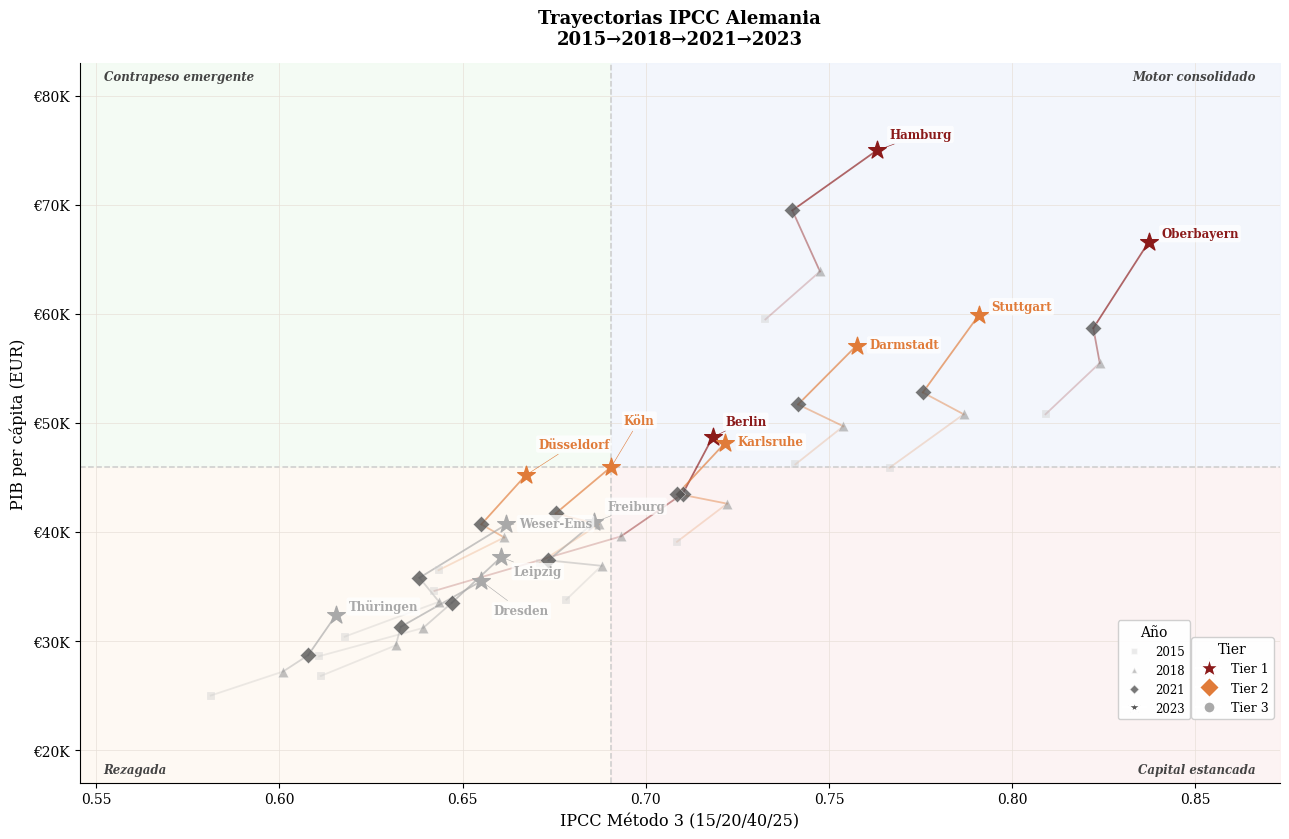

  ✓ Scatter: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_DE_scatter.png


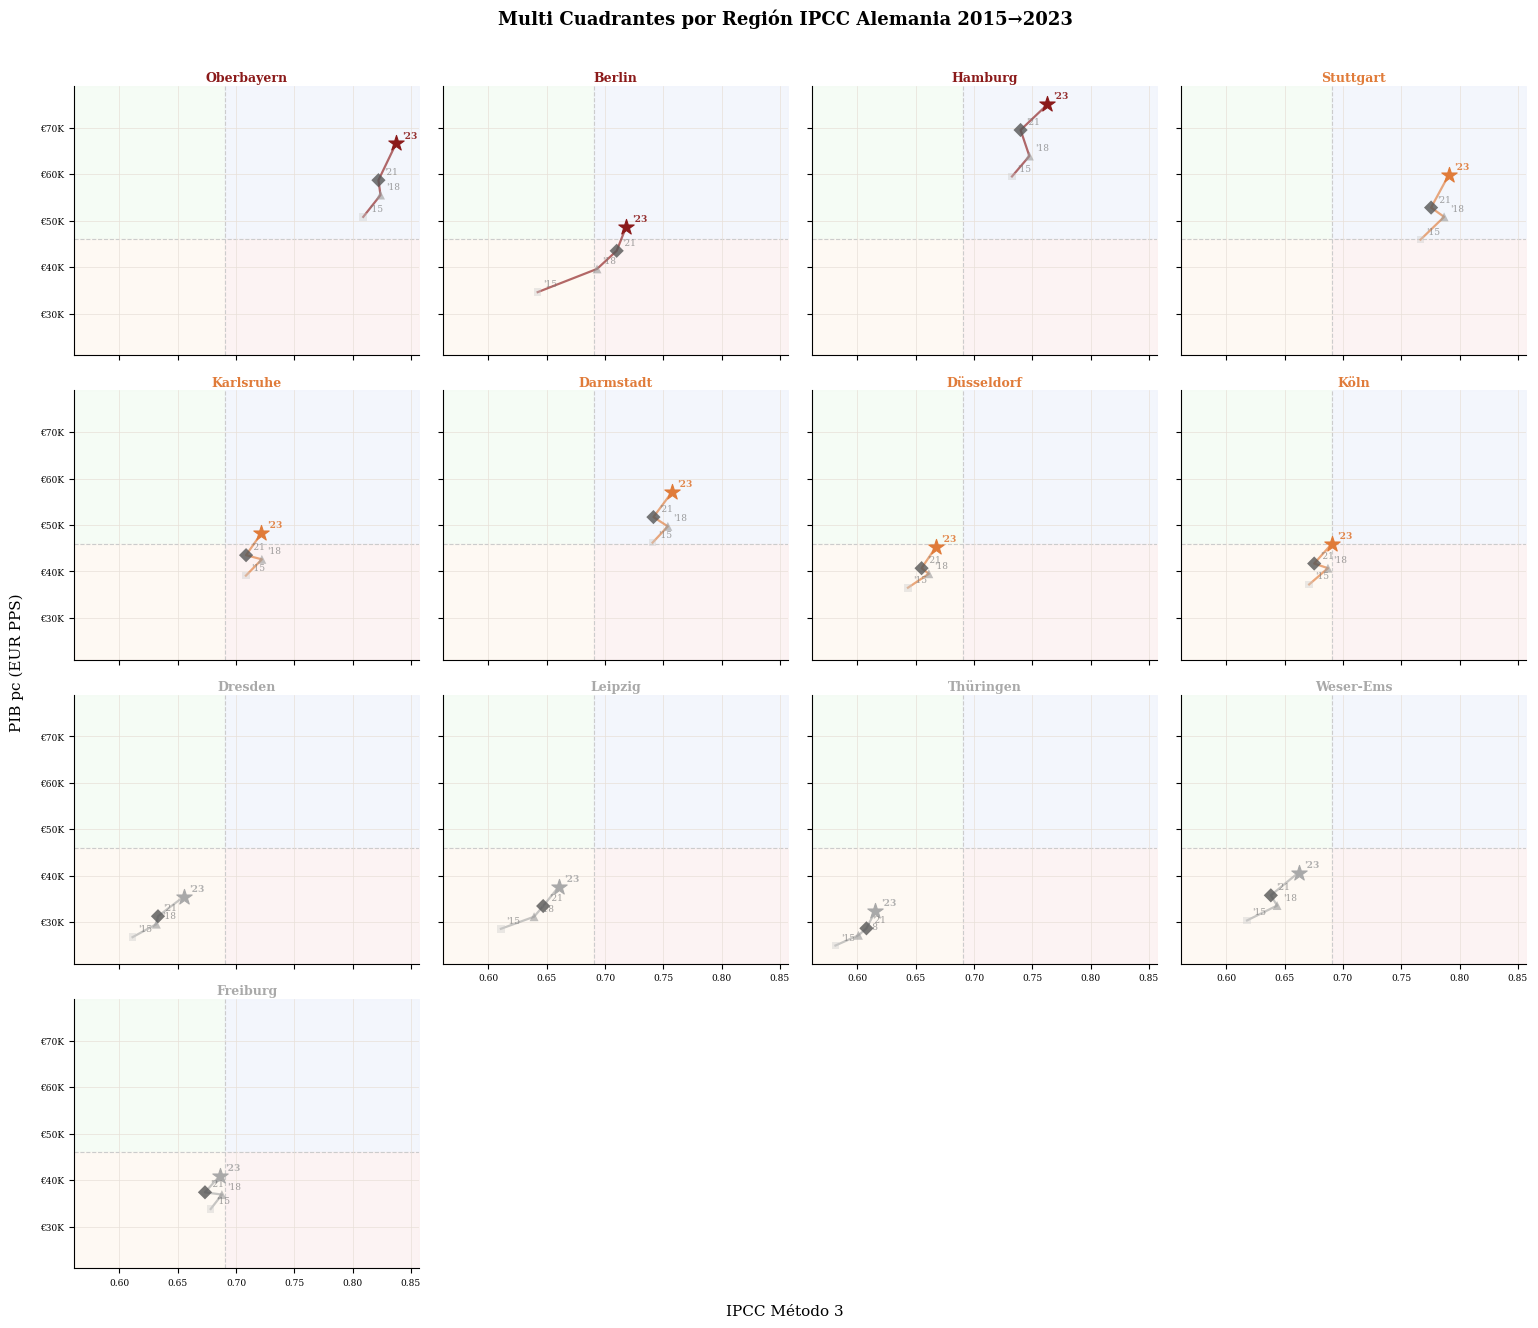

  ✓ Small multiples: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_DE_smallmult.png


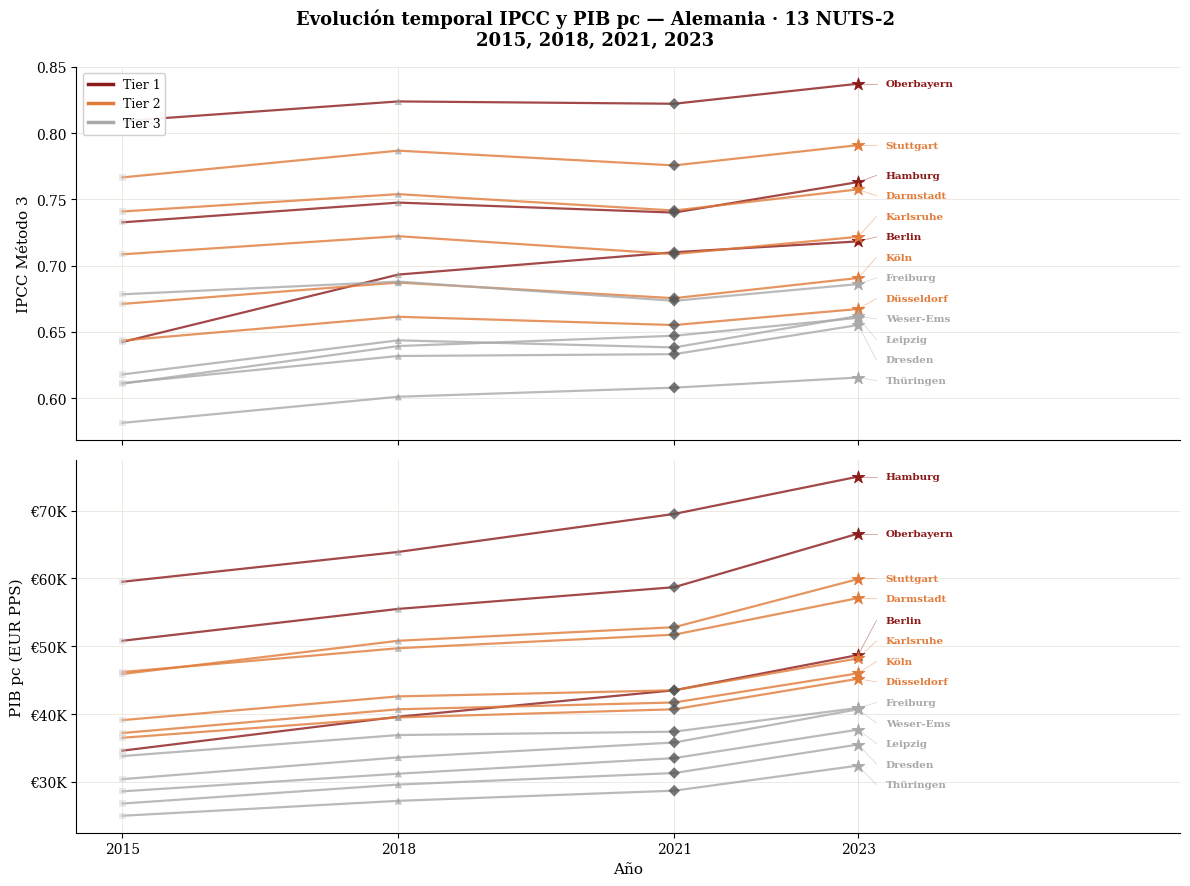

  ✓ Series temporales: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_DE_lineas.png

── España ──────────────────────────────


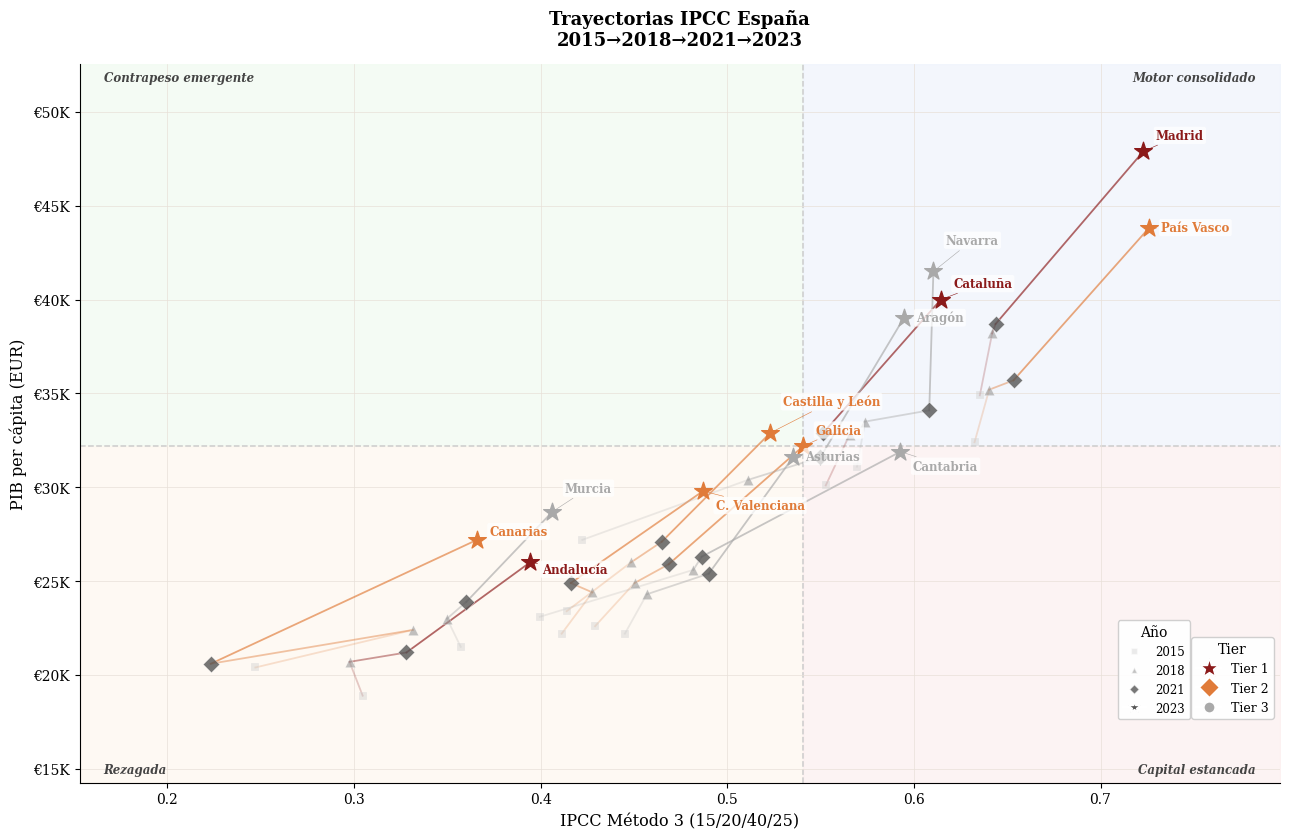

  ✓ Scatter: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_ES_scatter.png


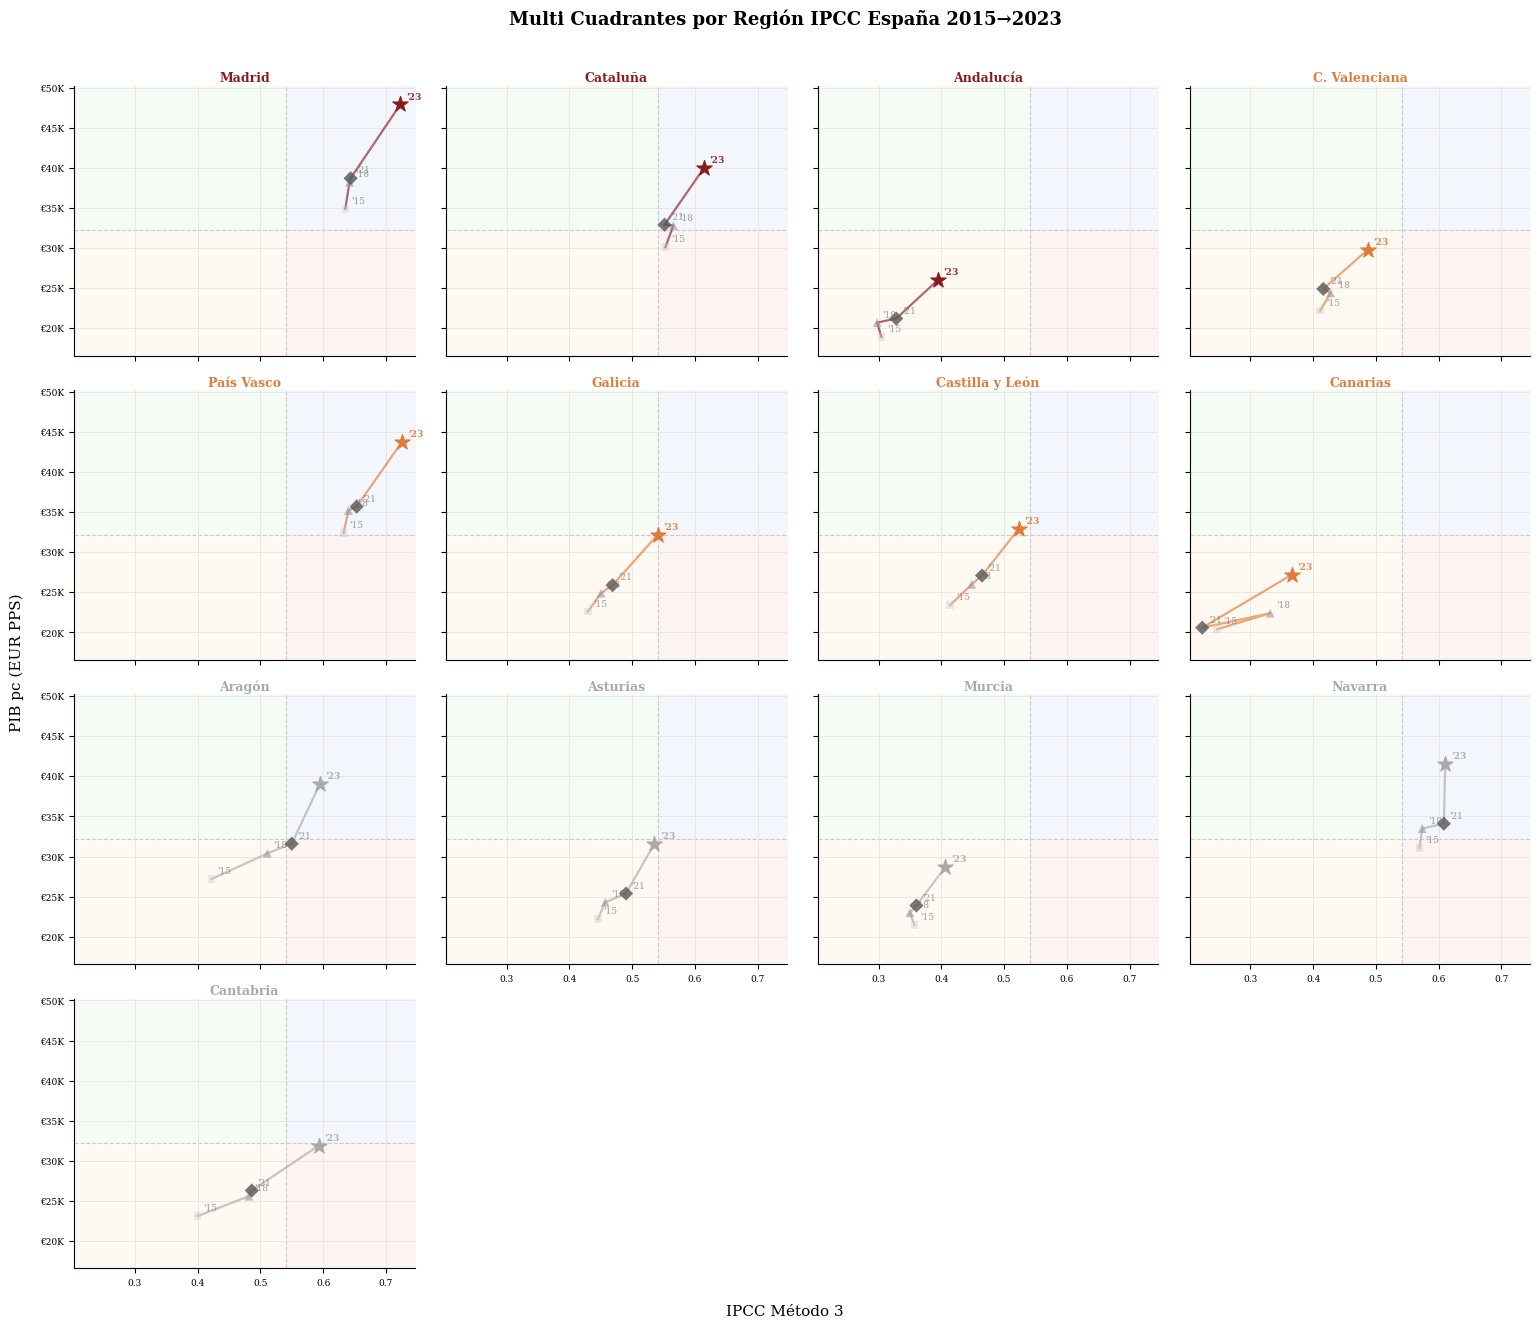

  ✓ Small multiples: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_ES_smallmult.png


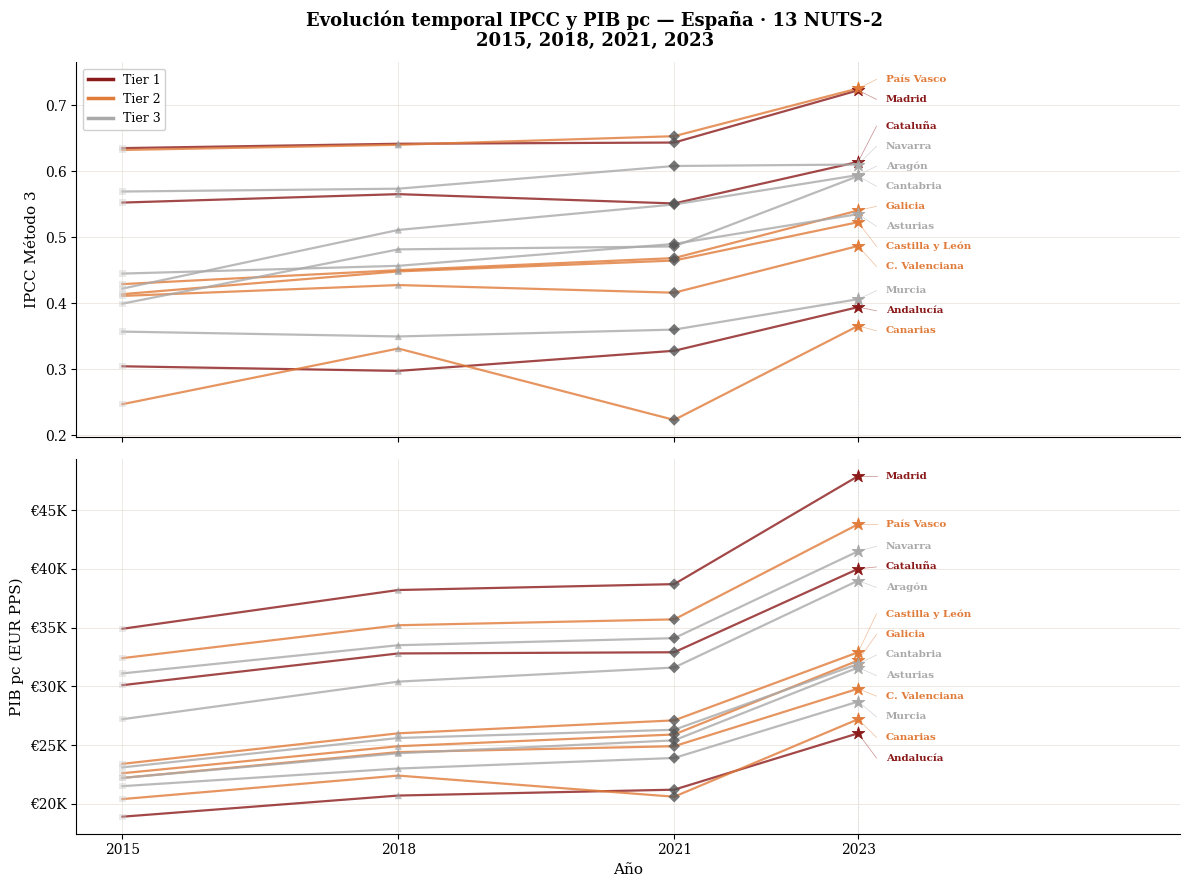

  ✓ Series temporales: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_ES_lineas.png

── Francia ──────────────────────────────


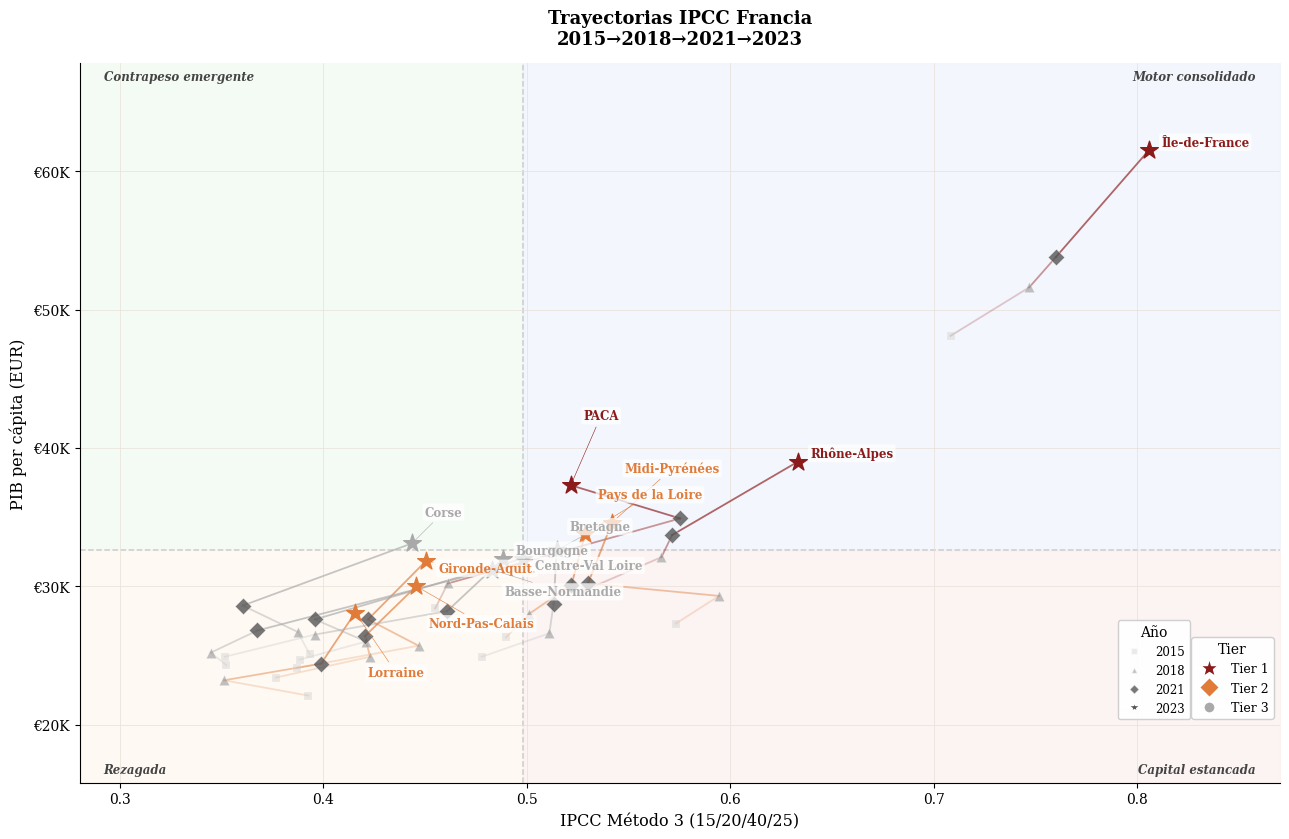

  ✓ Scatter: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_FR_scatter.png


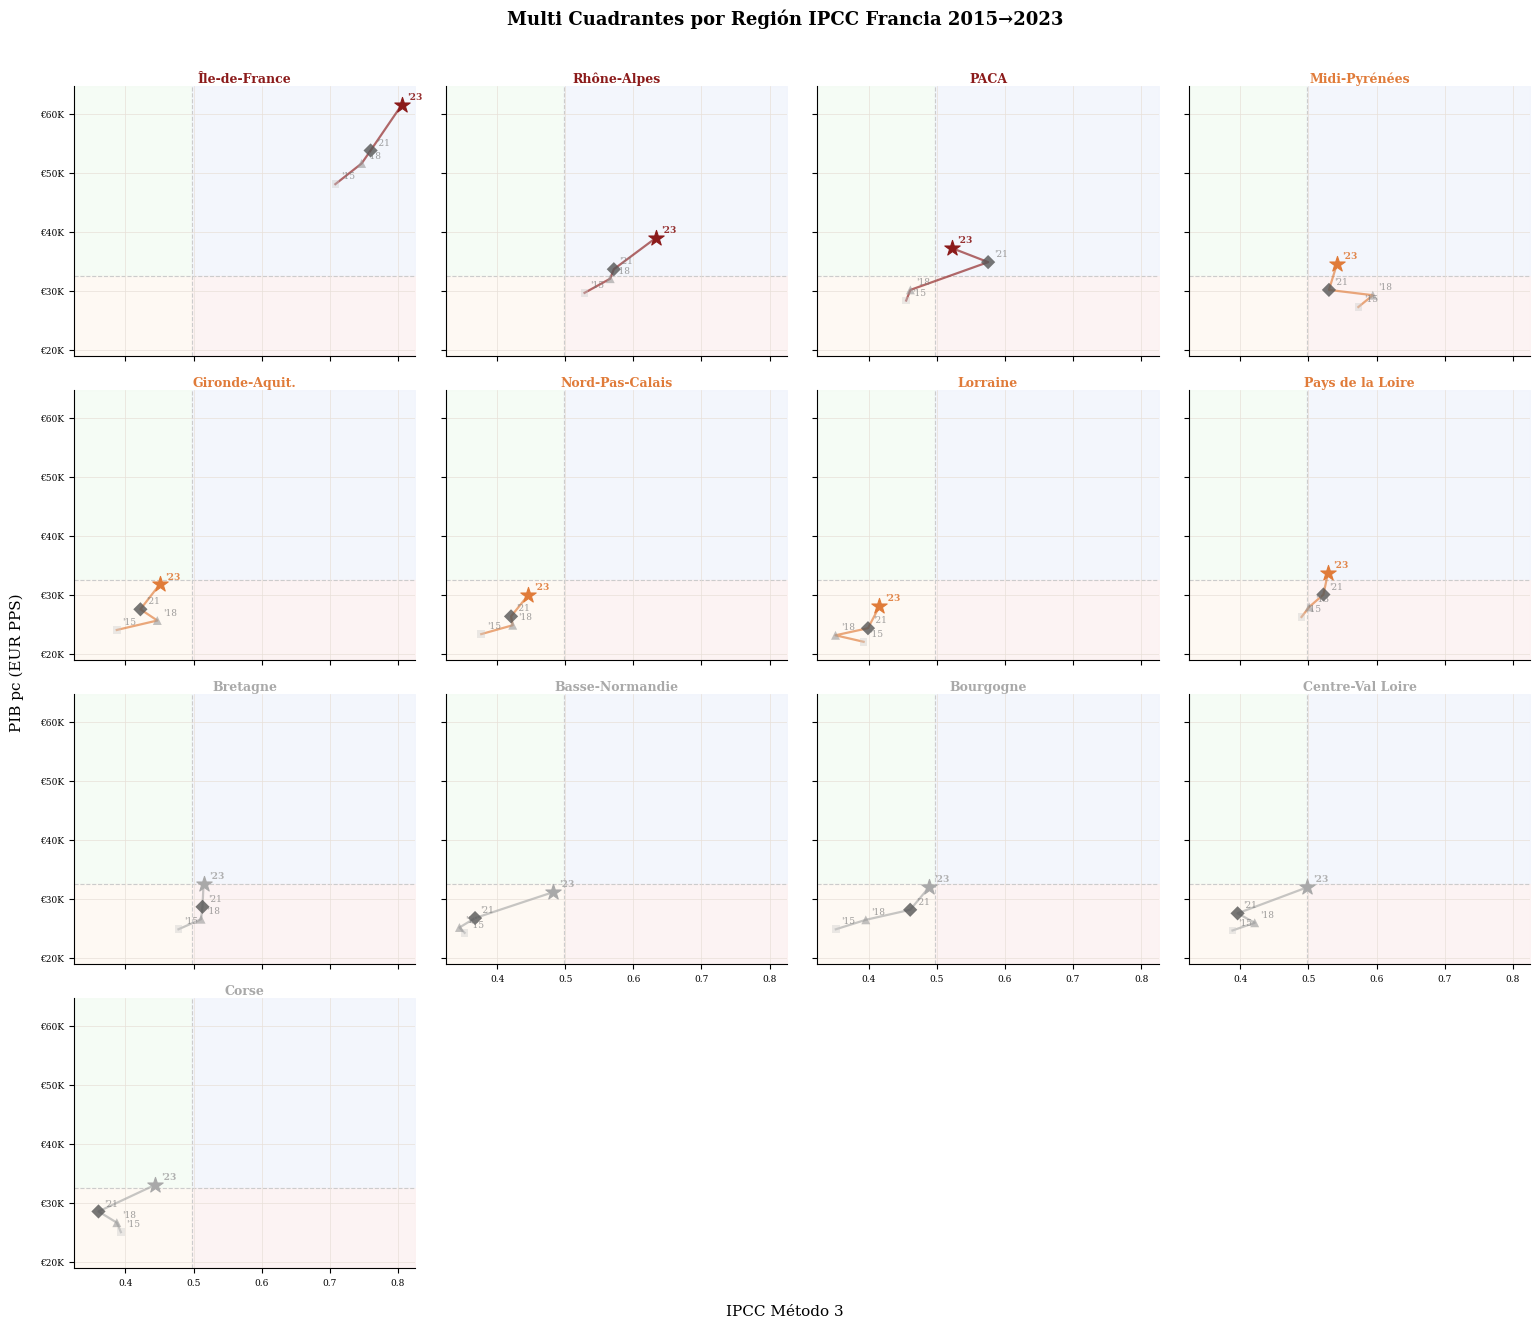

  ✓ Small multiples: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_FR_smallmult.png


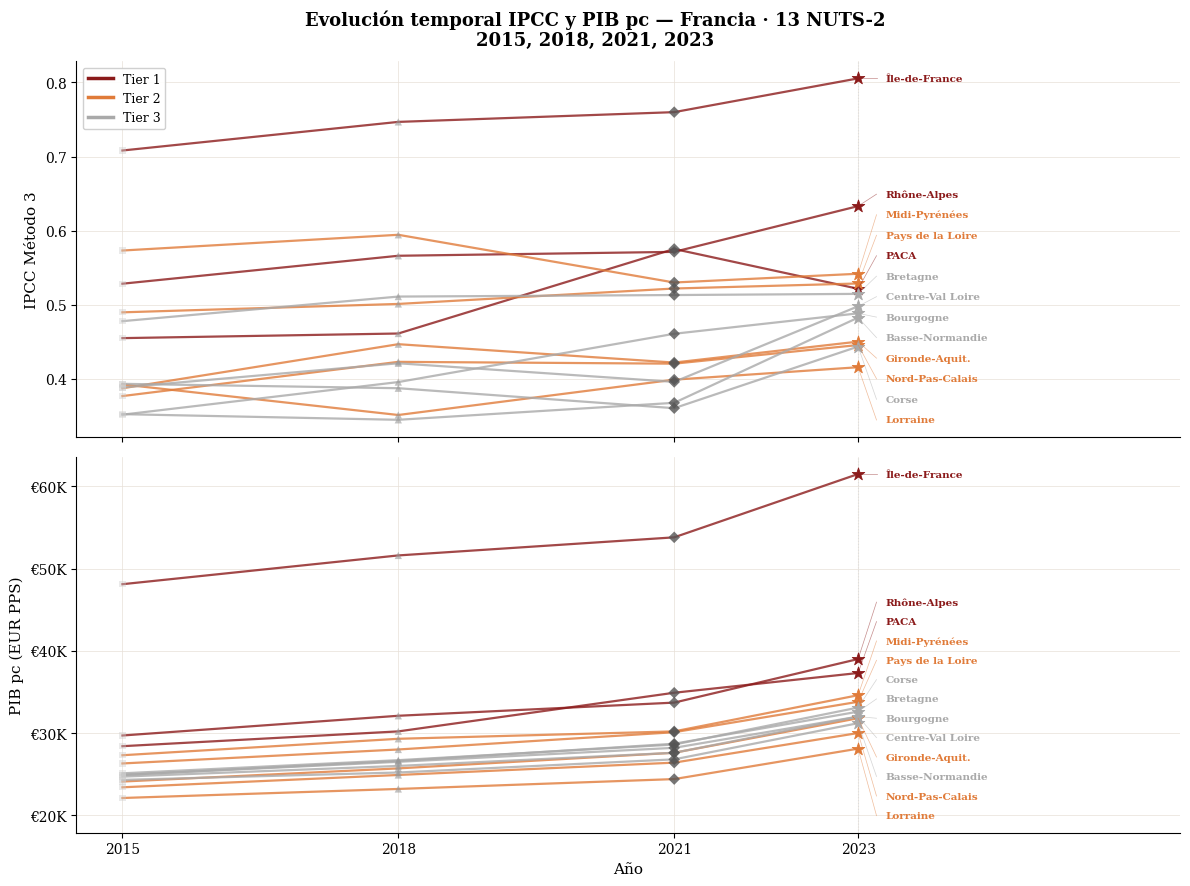

  ✓ Series temporales: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_FR_lineas.png

── EE.UU. ──────────────────────────────


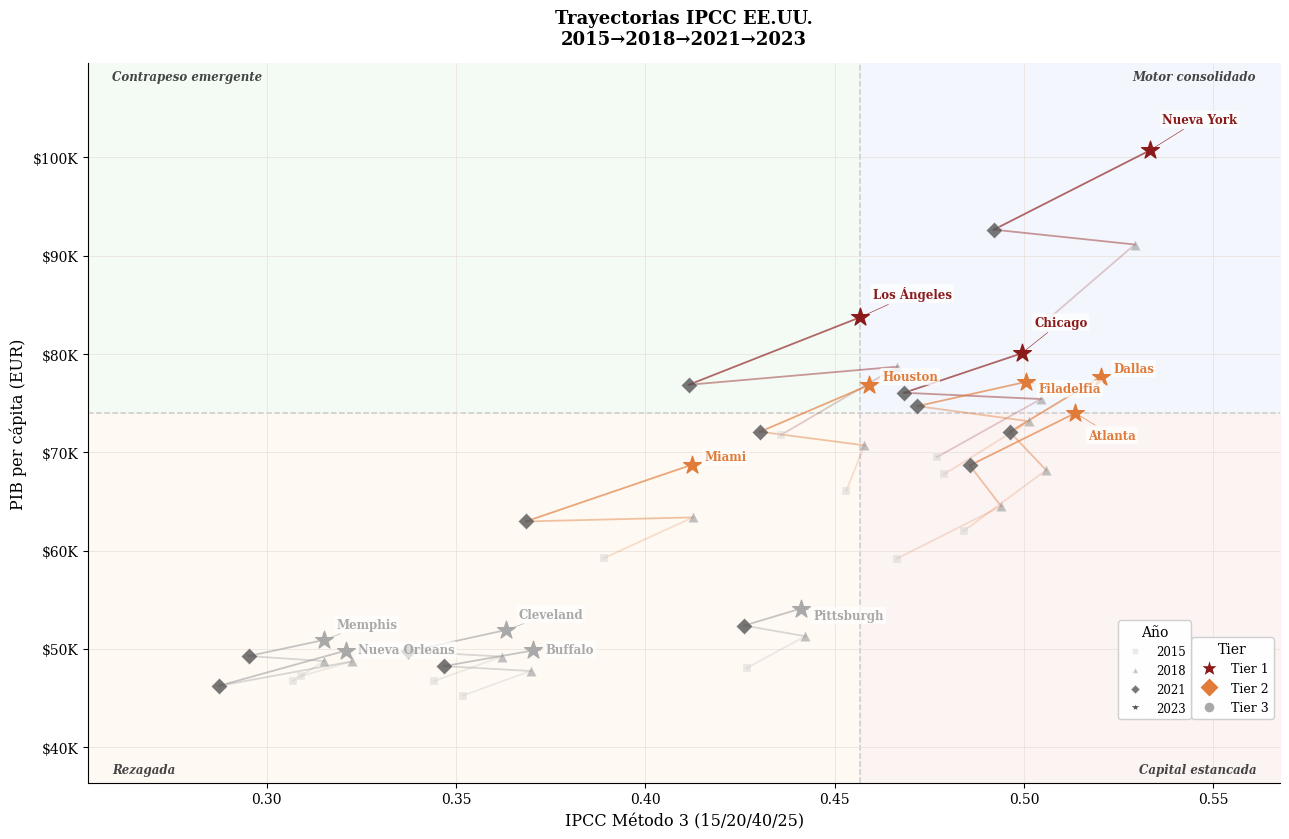

  ✓ Scatter: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_EEUU_scatter.png


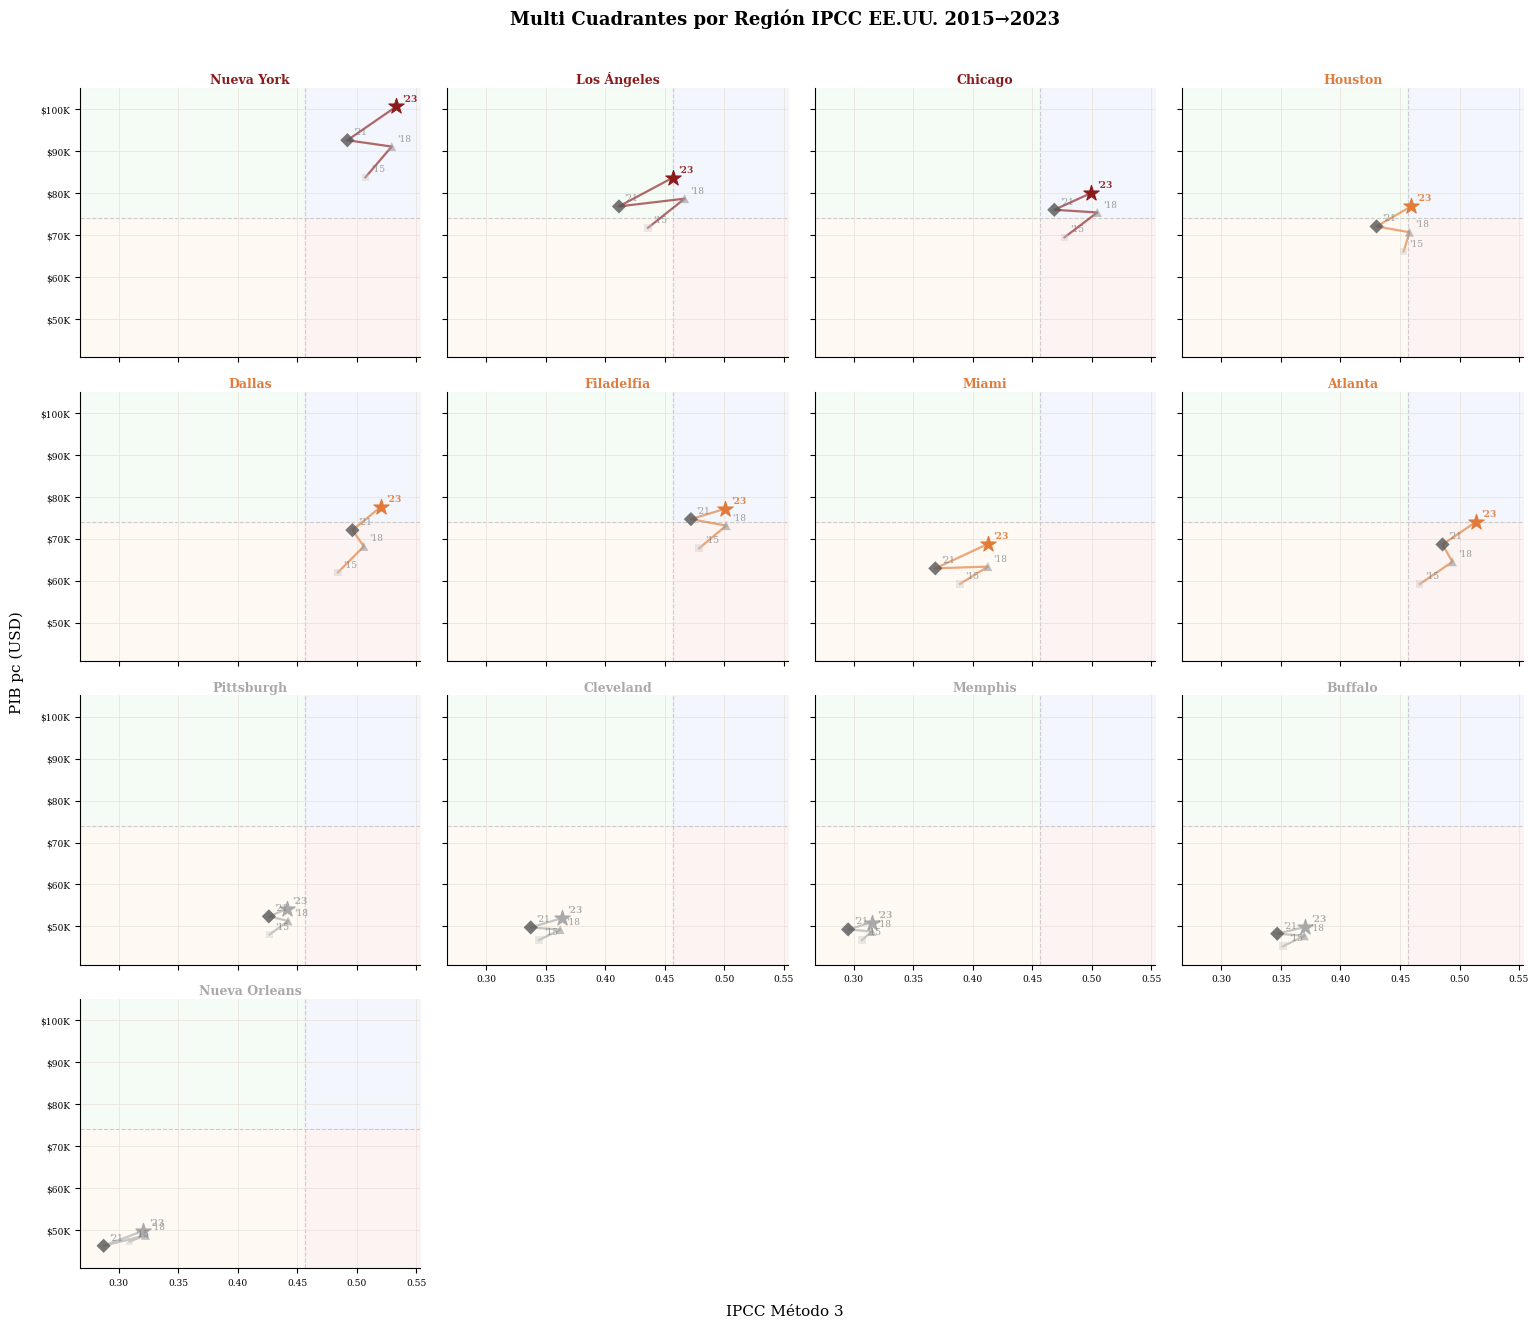

  ✓ Small multiples: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_EEUU_smallmult.png


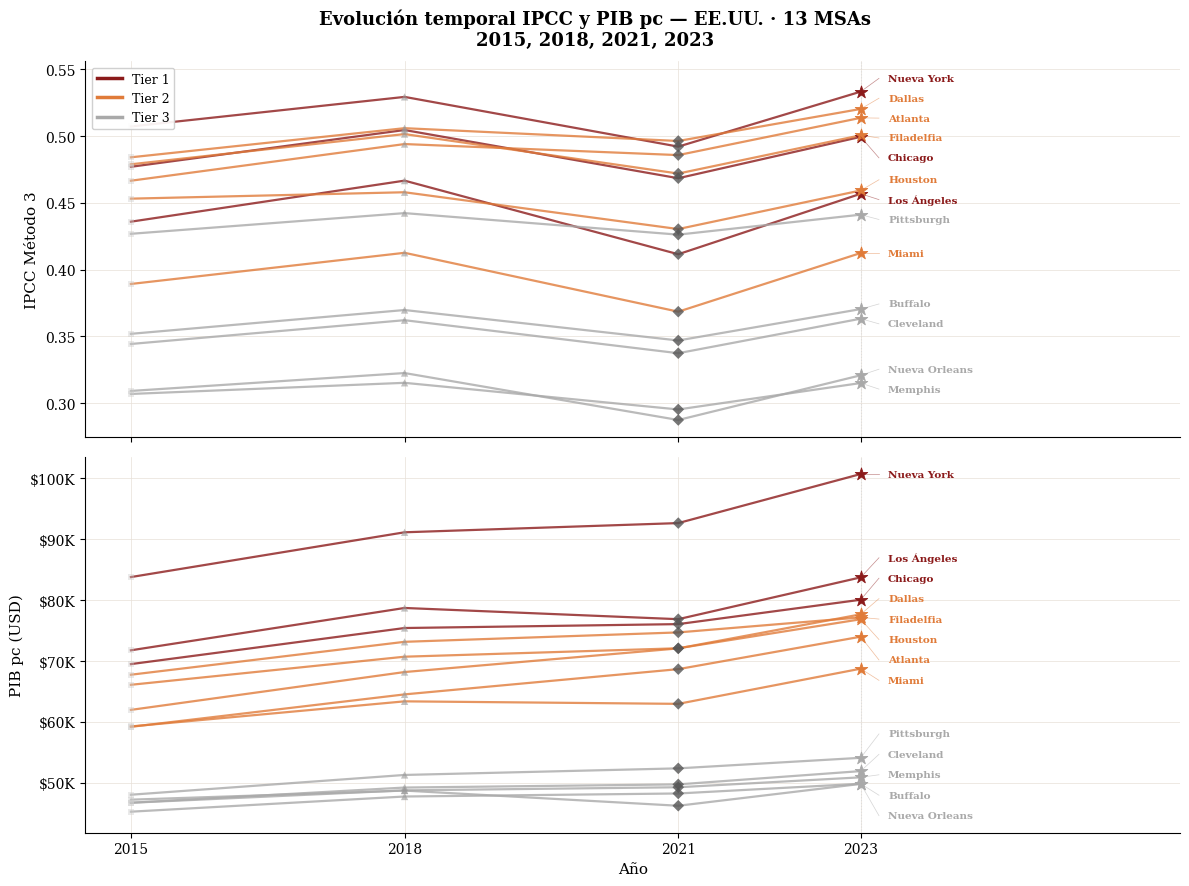

  ✓ Series temporales: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F_tray_EEUU_lineas.png

✓ 12 figuras generadas (3 tipos × 4 países)


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 3 — VISUALIZACIÓN DE TRAYECTORIAS (3 tipos de figura por país)
#
# Por cada país se generan:
#   F_tray_{P}_scatter.png   — Scatter CCPI × PIB pc con trayectorias superpuestas
#   F_tray_{P}_smallmult.png — Small multiples: una celda por región (sin solapamiento)
#   F_tray_{P}_lineas.png    — Series temporales CCPI y PIB pc por región
# ══════════════════════════════════════════════════════════════════════════════

MARKER_AÑO = {2015: 's', 2018: '^', 2021: 'D', 2023: '*'}
SIZE_AÑO   = {2015: 40,  2018: 55,  2021: 70,  2023: 180}
ALPHA_AÑO  = {2015: 0.40, 2018: 0.60, 2021: 0.80, 2023: 1.00}
COLOR_AÑO  = {2015: '#CCCCCC', 2018: '#999999', 2021: '#555555', 2023: None}

PAISES_FIG = [
    ('DE',   'Alemania', NUTS2_DE,   '13 NUTS-2', 'EUR PPS', '€{x/1_000:.0f}K'),
    ('ES',   'España',   NUTS2_ES,   '13 NUTS-2', 'EUR PPS', '€{x/1_000:.0f}K'),
    ('FR',   'Francia',  NUTS2_FR,   '13 NUTS-2', 'EUR PPS', '€{x/1_000:.0f}K'),
    ('EEUU', 'EE.UU.',   MSAS_EEUU,  '13 MSAs',   'USD',     '${x/1_000:.0f}K'),
]

# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN 1: Scatter CCPI × PIB pc (versión mejorada con etiquetas separadas)
# ─────────────────────────────────────────────────────────────────────────────
def fig_scatter(pais, nombre_pais, nuts_dict, descripcion, moneda, fmt_str, df_p):
    df_23    = df_p[df_p['anio'] == 2023]
    med_ccpi = float(df_23['CCPI_M3'].median())
    med_gdp  = float(df_23['gdp_pc'].median())
    pad_x    = (df_p['CCPI_M3'].max()-df_p['CCPI_M3'].min()) * 0.14
    pad_y    = (df_p['gdp_pc'].max()-df_p['gdp_pc'].min())   * 0.16
    xmin = df_p['CCPI_M3'].min()-pad_x; xmax = df_p['CCPI_M3'].max()+pad_x
    ymin = df_p['gdp_pc'].min()-pad_y;  ymax = df_p['gdp_pc'].max()+pad_y

    fig, ax = plt.subplots(figsize=(13, 8.5))
    fig.set_facecolor('white'); ax.set_facecolor('white')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.grid(True, color='#E8E0D8', linewidth=0.5)

    for (x0,x1,y0,y1), clr in [
        ((xmin,med_ccpi,med_gdp,ymax),'#F2FBF2'),((med_ccpi,xmax,med_gdp,ymax),'#F0F4FC'),
        ((xmin,med_ccpi,ymin,med_gdp),'#FEF8F0'),((med_ccpi,xmax,ymin,med_gdp),'#FCF0F0'),
    ]:
        ax.fill_betweenx([y0,y1], x0, x1, color=clr, alpha=0.80, zorder=0)
    ax.axvline(med_ccpi, color='#CCCCCC', lw=1.1, ls='--', zorder=1)
    ax.axhline(med_gdp,  color='#CCCCCC', lw=1.1, ls='--', zorder=1)

    kw_q = dict(fontsize=8.5, color='#444', fontstyle='italic',
                fontweight='semibold', fontfamily='DejaVu Serif', transform=ax.transAxes)
    ax.text(0.98,0.99,'Motor consolidado',    ha='right',va='top',   **kw_q)
    ax.text(0.02,0.99,'Contrapeso emergente',    ha='left', va='top',   **kw_q)
    ax.text(0.98,0.01,'Capital estancada', ha='right',va='bottom',**kw_q)
    ax.text(0.02,0.01,'Rezagada',             ha='left', va='bottom',**kw_q)
    etiquetas = []
    cx_mean = float(df_p['CCPI_M3'].mean())
    for geo, (nom, tier) in nuts_dict.items():
        df_r = df_p[df_p['cod']==geo].sort_values('anio')
        if df_r.empty: continue
        clr_t = COLOR_TIER[tier]
        xs = df_r['CCPI_M3'].values; ys = df_r['gdp_pc'].values
        for k in range(len(xs)-1):
            ax.plot(xs[k:k+2], ys[k:k+2], color=clr_t, lw=1.3, alpha=0.22+0.22*k, zorder=2)
        for _, rw in df_r.iterrows():
            yr_i = int(rw['anio'])
            clr_m = clr_t if yr_i==2023 else COLOR_AÑO[yr_i]
            ax.scatter(rw['CCPI_M3'], rw['gdp_pc'], color=clr_m,
                       s=SIZE_AÑO[yr_i], marker=MARKER_AÑO[yr_i],
                       alpha=ALPHA_AÑO[yr_i],
                       edgecolors=clr_t if yr_i==2023 else 'white',
                       linewidth=0.9 if yr_i==2023 else 0.3, zorder=4+AÑOS.index(yr_i))
        r23 = df_r[df_r['anio']==2023]
        if len(r23):
            etiquetas.append({'nom':nom,'tier':tier,
                              'cx':float(r23['CCPI_M3'].values[0]),
                              'cy':float(r23['gdp_pc'].values[0]),
                              'dx':9,'dy':6})

    rng_x = xmax-xmin+1e-9
    for _ in range(50):
        for i in range(len(etiquetas)):
            for j in range(i+1,len(etiquetas)):
                a,b = etiquetas[i],etiquetas[j]
                if abs(a['cx']-b['cx']) < rng_x*0.08 and abs(a['dy']-b['dy']) < 11:
                    sep = 5.5
                    if a['cy']>=b['cy']: a['dy']+=sep; b['dy']-=sep
                    else:                a['dy']-=sep; b['dy']+=sep

    for e in etiquetas:
        clr_t = COLOR_TIER[e['tier']]
        ax.annotate(e['nom'], xy=(e['cx'],e['cy']), xytext=(e['dx'],e['dy']),
                    textcoords='offset points', fontsize=8.5,
                    fontfamily='DejaVu Serif', color=clr_t, fontweight='semibold',
                    va='center', ha='left' if e['dx']>=0 else 'right',
                    arrowprops=dict(arrowstyle='-',color=clr_t,lw=0.4),
                    bbox=dict(boxstyle='round,pad=0.18',fc='white',ec='none',alpha=0.75),
                    zorder=7)

    leg_tier = [
        Line2D([0],[0],marker='*',color='w',markerfacecolor=COLOR_TIER[1],markersize=14,label='Tier 1'),
        Line2D([0],[0],marker='D',color='w',markerfacecolor=COLOR_TIER[2],markersize=10,label='Tier 2'),
        Line2D([0],[0],marker='o',color='w',markerfacecolor=COLOR_TIER[3],markersize=8, label='Tier 3'),
    ]
    leg_yr = [
        Line2D([0],[0],marker=MARKER_AÑO[yr],color='w',
               markerfacecolor=COLOR_AÑO[yr] if yr!=2023 else '#555',
               markersize=np.sqrt(SIZE_AÑO[yr])*0.65, alpha=ALPHA_AÑO[yr], label=str(yr))
        for yr in AÑOS
    ]
    l1 = ax.legend(handles=leg_tier, fontsize=9, loc='lower right', frameon=True,
               framealpha=0.92, title='Tier', bbox_to_anchor=(1.0, 0.08))
    ax.add_artist(l1)
    ax.legend(handles=leg_yr, fontsize=8.5, loc='lower right', frameon=True,
          framealpha=0.92, title='Año', bbox_to_anchor=(0.93, 0.08))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: eval(f'f"{fmt_str}"')))
    ax.set_xlabel('IPCC Método 3 (15/20/40/25)', fontfamily='DejaVu Serif', fontsize=11.5)
    ax.set_ylabel(f'PIB per cápita (EUR)',   fontfamily='DejaVu Serif', fontsize=11.5)
    ax.set_xlim(xmin,xmax); ax.set_ylim(ymin,ymax)
    ax.set_title(f'Trayectorias IPCC {nombre_pais}\n'
                 f'2015→2018→2021→2023',
                 fontfamily='DejaVu Serif',fontsize=13,fontweight='bold',pad=14)
    plt.tight_layout()
    ruta = f'{BASE_FIGURAS}/F_tray_{pais}_scatter.png'
    fig.savefig(ruta,dpi=300,bbox_inches='tight',facecolor='white')
    display(fig); plt.close()
    print(f'  ✓ Scatter: {ruta}')

# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN 2: Small multiples — una celda por región (sin solapamiento)
# ─────────────────────────────────────────────────────────────────────────────
def fig_smallmult(pais, nombre_pais, nuts_dict, descripcion, moneda, fmt_str, df_p):
    regiones = list(nuts_dict.items())   # [(geo,(nom,tier)), ...]
    n = len(regiones)
    ncols = 4; nrows = (n + ncols - 1) // ncols  # 4 columnas

    # Límites globales compartidos
    xmin_g = df_p['CCPI_M3'].min() - 0.02
    xmax_g = df_p['CCPI_M3'].max() + 0.02
    ymin_g = df_p['gdp_pc'].min()  - (df_p['gdp_pc'].max()-df_p['gdp_pc'].min())*0.08
    ymax_g = df_p['gdp_pc'].max()  + (df_p['gdp_pc'].max()-df_p['gdp_pc'].min())*0.08

    # Medianas 2023 globales del país
    df_23    = df_p[df_p['anio']==2023]
    med_ccpi = float(df_23['CCPI_M3'].median())
    med_gdp  = float(df_23['gdp_pc'].median())

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.8, nrows*3.2), squeeze=False)
    fig.set_facecolor('white')

    for idx, (geo, (nom, tier)) in enumerate(regiones):
        row_i = idx // ncols; col_i = idx % ncols
        ax = axes[row_i][col_i]
        ax.set_facecolor('white')
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
        ax.grid(True, color='#E8E0D8', linewidth=0.5)

        # Fondo cuadrante (suave)
        for (x0,x1,y0,y1), clr in [
            ((xmin_g,med_ccpi,med_gdp,ymax_g),'#F2FBF2'),
            ((med_ccpi,xmax_g,med_gdp,ymax_g),'#F0F4FC'),
            ((xmin_g,med_ccpi,ymin_g,med_gdp),'#FEF8F0'),
            ((med_ccpi,xmax_g,ymin_g,med_gdp),'#FCF0F0'),
        ]:
            ax.fill_betweenx([y0,y1], x0, x1, color=clr, alpha=0.75, zorder=0)
        ax.axvline(med_ccpi, color='#CCCCCC', lw=0.8, ls='--', zorder=1)
        ax.axhline(med_gdp,  color='#CCCCCC', lw=0.8, ls='--', zorder=1)

        clr_t = COLOR_TIER[tier]
        df_r  = df_p[df_p['cod']==geo].sort_values('anio')

        if not df_r.empty:
            xs = df_r['CCPI_M3'].values; ys = df_r['gdp_pc'].values
            # Línea de trayectoria completa
            ax.plot(xs, ys, color=clr_t, lw=1.6, alpha=0.65, zorder=2)
            # Marcadores y etiquetas de año en cada punto
            for _, rw in df_r.iterrows():
                yr_i  = int(rw['anio'])
                clr_m = clr_t if yr_i==2023 else COLOR_AÑO[yr_i]
                ax.scatter(rw['CCPI_M3'], rw['gdp_pc'],
                           color=clr_m, s=SIZE_AÑO[yr_i]*0.75,
                           marker=MARKER_AÑO[yr_i],
                           alpha=ALPHA_AÑO[yr_i],
                           edgecolors=clr_t if yr_i==2023 else 'none',
                           linewidth=0.8, zorder=4)
                # Etiqueta del año en cada punto
                ax.annotate(f"'{str(yr_i)[2:]}",
                            xy=(rw['CCPI_M3'], rw['gdp_pc']),
                            xytext=(4, 4), textcoords='offset points',
                            fontsize=6.5, fontfamily='DejaVu Serif',
                            color=clr_t if yr_i==2023 else '#777',
                            fontweight='bold' if yr_i==2023 else 'normal',
                            alpha=0.9 if yr_i==2023 else 0.7, zorder=5)

        # Título del panel = nombre de la región
        ax.set_title(nom, fontfamily='DejaVu Serif', fontsize=9,
                     fontweight='bold', color=clr_t, pad=3)
        ax.set_xlim(xmin_g, xmax_g)
        ax.set_ylim(ymin_g, ymax_g)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: eval(f'f"{fmt_str}"')))
        ax.tick_params(labelsize=6.5)

        # Solo etiquetas de eje en borde izquierdo y borde inferior
        if col_i != 0:
            ax.set_yticklabels([])
        if row_i != nrows-1 and idx+ncols < n:
            ax.set_xticklabels([])

    # Ocultar paneles vacíos
    for idx in range(len(regiones), nrows*ncols):
        axes[idx//ncols][idx%ncols].set_visible(False)

    fig.suptitle(f'Multi Cuadrantes por Región IPCC {nombre_pais}'
                 f' 2015→2023',
                 fontfamily='DejaVu Serif', fontsize=13, fontweight='bold', y=1.01)
    fig.text(0.5, -0.01, 'IPCC Método 3', ha='center',
             fontfamily='DejaVu Serif', fontsize=11)
    fig.text(-0.01, 0.5, f'PIB pc ({moneda})', va='center', rotation='vertical',
             fontfamily='DejaVu Serif', fontsize=11)
    plt.tight_layout()
    ruta = f'{BASE_FIGURAS}/F_tray_{pais}_smallmult.png'
    fig.savefig(ruta, dpi=300, bbox_inches='tight', facecolor='white')
    display(fig); plt.close()
    print(f'  ✓ Small multiples: {ruta}')

# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN 3: Series temporales CCPI y PIB pc por región (2 subplots)
# ─────────────────────────────────────────────────────────────────────────────
def fig_lineas(pais, nombre_pais, nuts_dict, descripcion, moneda, fmt_str, df_p):
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
    fig.set_facecolor('white')

    for ax in (ax_top, ax_bot):
        ax.set_facecolor('white')
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
        ax.grid(True, color='#E8E0D8', linewidth=0.5)

    # Pre-calcular posiciones finales para etiquetas (año 2023, eje derecho)
    etiq_ccpi = []; etiq_gdp = []

    for geo, (nom, tier) in nuts_dict.items():
        df_r  = df_p[df_p['cod']==geo].sort_values('anio')
        if df_r.empty: continue
        clr_t = COLOR_TIER[tier]
        años_r = df_r['anio'].values
        ccpis  = df_r['CCPI_M3'].values
        gdps   = df_r['gdp_pc'].values

        # ── Panel superior: CCPI_M3 ────────────────────────────────────────
        ax_top.plot(años_r, ccpis, color=clr_t, lw=1.6, alpha=0.80, zorder=3)
        for k, (yr_i, ccpi_v) in enumerate(zip(años_r, ccpis)):
            ax_top.scatter(yr_i, ccpi_v,
                           color=clr_t if yr_i==2023 else COLOR_AÑO[yr_i],
                           s=SIZE_AÑO[yr_i]*0.5, marker=MARKER_AÑO[yr_i],
                           alpha=ALPHA_AÑO[yr_i],
                           edgecolors=clr_t if yr_i==2023 else 'none',
                           linewidth=0.6, zorder=4)
        # Etiqueta al final (2023)
        etiq_ccpi.append({'nom': nom, 'tier': tier,
                           'y': float(ccpis[-1]), 'dy': 0})

        # ── Panel inferior: PIB pc ─────────────────────────────────────────
        ax_bot.plot(años_r, gdps, color=clr_t, lw=1.6, alpha=0.80, zorder=3)
        for yr_i, gdp_v in zip(años_r, gdps):
            ax_bot.scatter(yr_i, gdp_v,
                           color=clr_t if yr_i==2023 else COLOR_AÑO[yr_i],
                           s=SIZE_AÑO[yr_i]*0.5, marker=MARKER_AÑO[yr_i],
                           alpha=ALPHA_AÑO[yr_i],
                           edgecolors=clr_t if yr_i==2023 else 'none',
                           linewidth=0.6, zorder=4)
        etiq_gdp.append({'nom': nom, 'tier': tier,
                          'y': float(gdps[-1]),  'dy': 0})

    # Anti-colisión etiquetas eje derecho (dy en unidades de datos)
    fig.canvas.draw()   # fuerza cálculo de límites reales
    for ax_e, etiq in [(ax_top, etiq_ccpi), (ax_bot, etiq_gdp)]:
        rng = ax_e.get_ylim()[1] - ax_e.get_ylim()[0]
        etiq.sort(key=lambda e: e['y'], reverse=True)
        min_sep = rng * 0.055
        for _ in range(60):
            for i in range(len(etiq)-1):
                a, b = etiq[i], etiq[i+1]
                sep = (a['y'] + a['dy']) - (b['y'] + b['dy'])
                if sep < min_sep:
                    gap = (min_sep - sep) / 2
                    a['dy'] += gap; b['dy'] -= gap

    # Ampliar eje x para dejar espacio a etiquetas
    ax_bot.set_xlim(AÑOS[0] - 0.5, 2026.5)

    for ax_e, etiq in [(ax_top, etiq_ccpi), (ax_bot, etiq_gdp)]:
        for e in etiq:
            clr_t = COLOR_TIER[e['tier']]
            y_pos = e['y'] + e['dy']
            ax_e.plot([2023, 2023.2], [e['y'], y_pos],
                      color=clr_t, lw=0.5, alpha=0.5, zorder=5)
            ax_e.text(2023.3, y_pos, e['nom'],
                      fontsize=7.5, fontfamily='DejaVu Serif',
                      color=clr_t, fontweight='semibold',
                      va='center', ha='left', zorder=6)

    # Línea vertical en 2023 (referencia)
    for ax_e in (ax_top, ax_bot):
        ax_e.axvline(2023, color='#DDDDDD', lw=0.8, ls=':')

    ax_top.set_ylabel('IPCC Método 3', fontfamily='DejaVu Serif', fontsize=11)
    ax_bot.set_ylabel(f'PIB pc ({moneda})', fontfamily='DejaVu Serif', fontsize=11)
    ax_bot.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: eval(f'f"{fmt_str}"')))
    ax_bot.set_xlabel('Año', fontfamily='DejaVu Serif', fontsize=11)
    ax_bot.set_xticks(AÑOS)

    # Leyenda
    leg = [
        Line2D([0],[0],color=COLOR_TIER[1],lw=2.5,label='Tier 1'),
        Line2D([0],[0],color=COLOR_TIER[2],lw=2.5,label='Tier 2'),
        Line2D([0],[0],color=COLOR_TIER[3],lw=2.5,label='Tier 3'),
    ]
    ax_top.legend(handles=leg, fontsize=9, loc='upper left',
                  frameon=True, framealpha=0.92)

    fig.suptitle(f'Evolución temporal IPCC y PIB pc — {nombre_pais} · {descripcion}\n'
                 f'2015, 2018, 2021, 2023',
                 fontfamily='DejaVu Serif', fontsize=13, fontweight='bold')
    plt.tight_layout()
    ruta = f'{BASE_FIGURAS}/F_tray_{pais}_lineas.png'
    fig.savefig(ruta, dpi=300, bbox_inches='tight', facecolor='white')
    display(fig); plt.close()
    print(f'  ✓ Series temporales: {ruta}')

# ─────────────────────────────────────────────────────────────────────────────
# EJECUCIÓN: 3 figuras × 4 países = 12 figuras
# ─────────────────────────────────────────────────────────────────────────────
for pais, nombre_pais, nuts_dict, descripcion, moneda, fmt_str in PAISES_FIG:
    df_p = df_traj[df_traj['pais'] == pais].copy()
    print(f'\n── {nombre_pais} ──────────────────────────────')
    fig_scatter(   pais, nombre_pais, nuts_dict, descripcion, moneda, fmt_str, df_p)
    fig_smallmult( pais, nombre_pais, nuts_dict, descripcion, moneda, fmt_str, df_p)
    fig_lineas(    pais, nombre_pais, nuts_dict, descripcion, moneda, fmt_str, df_p)

print('\n✓ 12 figuras generadas (3 tipos × 4 países)')


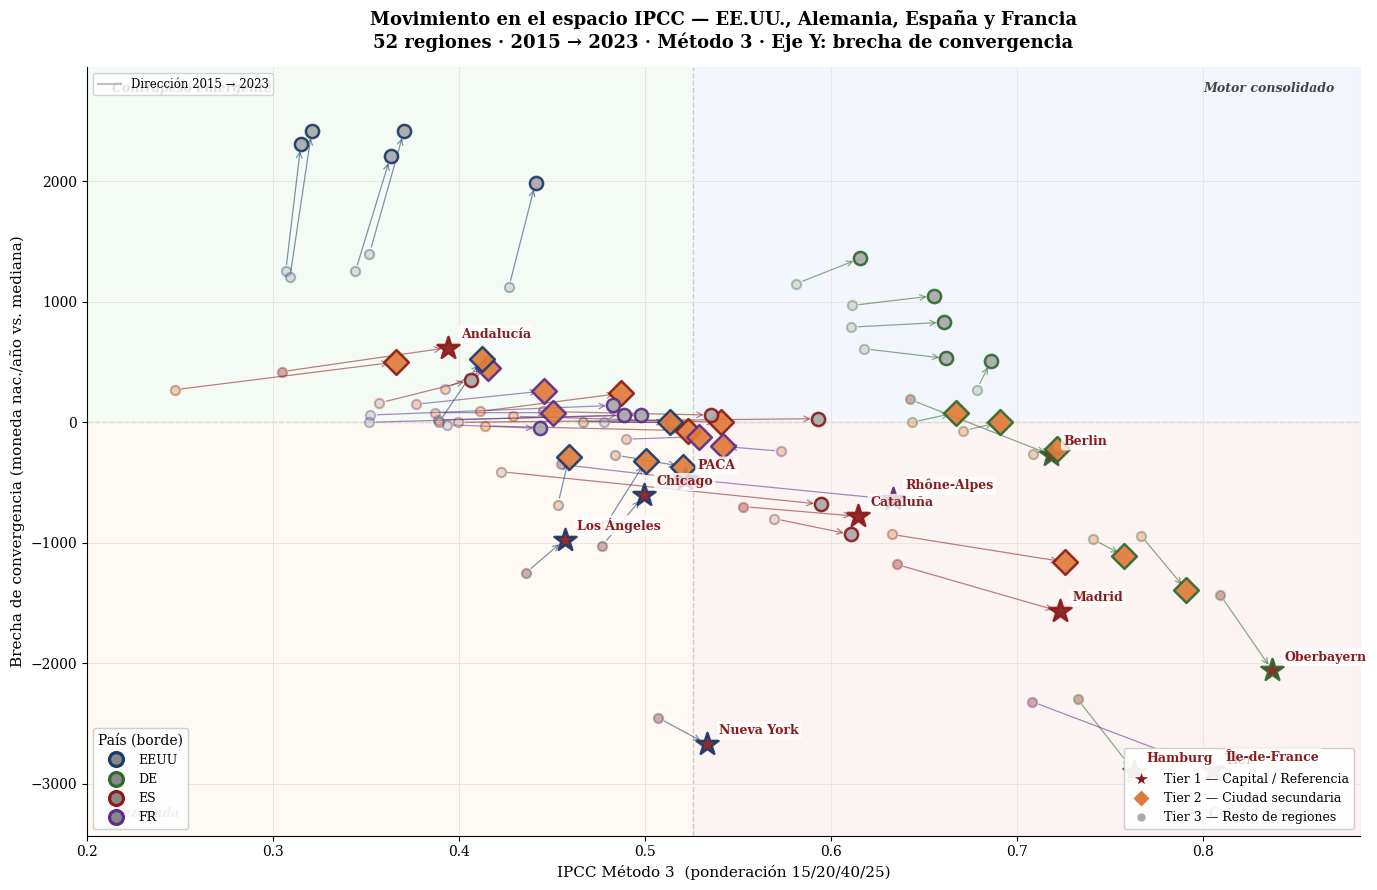

✓ Figura combinada guardada: /Users/diego/Desktop/MT/prototipo_ccpi/figures/F4_trayectorias_combinado.png


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 4 — FIGURA COMBINADA: 52 REGIONES · FLECHAS 2015 → 2023
# ══════════════════════════════════════════════════════════════════════════════
df_2015 = df_traj[df_traj['anio'] == 2015].set_index('cod')
df_2023 = df_traj[df_traj['anio'] == 2023].set_index('cod')
comun   = df_2015.index.intersection(df_2023.index)

# Medianas del pool combinado 2023
med_x_comb = float(df_2023['CCPI_M3'].median())
med_y_comb = float(df_2023['conv_pc'].median())

fig4, ax4 = plt.subplots(figsize=(14, 9))

all_x  = list(df_2015['CCPI_M3']) + list(df_2023['CCPI_M3'])
all_y  = list(df_2015['conv_pc']) + list(df_2023['conv_pc'])
pad_x  = (max(all_x) - min(all_x)) * 0.08
pad_y  = (max(all_y) - min(all_y)) * 0.10
xmin4 = min(all_x)-pad_x; xmax4 = max(all_x)+pad_x
ymin4 = min(all_y)-pad_y; ymax4 = max(all_y)+pad_y

for (x0, x1, y0, y1), clr in [
    ((xmin4, med_x_comb, med_y_comb, ymax4), '#F2FBF2'),
    ((med_x_comb, xmax4, med_y_comb, ymax4), '#F0F4FC'),
    ((xmin4, med_x_comb, ymin4, med_y_comb), '#FEF8F0'),
    ((med_x_comb, xmax4, ymin4, med_y_comb), '#FCF0F0'),
]:
    ax4.fill_betweenx([y0, y1], x0, x1, color=clr, alpha=0.8, zorder=0)

ax4.axvline(med_x_comb, color='#CCCCCC', lw=1, ls='--', zorder=1)
ax4.axhline(med_y_comb, color='#CCCCCC', lw=1, ls='--', zorder=1)

kw_q4 = dict(fontsize=9, color='#444', fontstyle='italic',
             fontweight='semibold', fontfamily='DejaVu Serif',
             transform=ax4.transAxes)
ax4.text(0.98, 0.98, 'Motor consolidado',    ha='right', va='top',    **kw_q4)
ax4.text(0.02, 0.98, 'Contrapeso emergente', ha='left',  va='top',    **kw_q4)
ax4.text(0.98, 0.02, 'Capital estancada',    ha='right', va='bottom', **kw_q4)
ax4.text(0.02, 0.02, 'Rezagada',             ha='left',  va='bottom', **kw_q4)

for cod in comun:
    r15  = df_2015.loc[cod]; r23 = df_2023.loc[cod]
    pais = str(r15['pais']); tier = int(r15['tier'])
    c_pais = COLOR_PAIS[pais]; c_tier = COLOR_TIER[tier]
    x0_p = float(r15['CCPI_M3']); y0_p = float(r15['conv_pc'])
    x1_p = float(r23['CCPI_M3']); y1_p = float(r23['conv_pc'])

    if abs(x1_p - x0_p) > 0.003 or abs(y1_p - y0_p) > 100:
        ax4.annotate('', xy=(x1_p, y1_p), xytext=(x0_p, y0_p),
                     arrowprops=dict(arrowstyle='->', color=c_pais,
                                     lw=0.9, alpha=0.55, shrinkA=5, shrinkB=5))

    # 2015: pequeño y semitransparente
    ax4.scatter(x0_p, y0_p, color=c_tier, s=45, marker='o',
                edgecolors=c_pais, linewidth=1.5, alpha=0.35, zorder=4)
    # 2023: tamaño normal con marcador de tier
    ax4.scatter(x1_p, y1_p, color=c_tier, s=SIZE_TIER[tier],
                marker=MARKER_TIER[tier],
                edgecolors=c_pais, linewidth=1.8, alpha=0.92, zorder=5)

    # Etiqueta solo Tier 1
    if tier == 1:
        ax4.annotate(str(r23['region']),
                     xy=(x1_p, y1_p), xytext=(9, 5), textcoords='offset points',
                     fontsize=9, fontfamily='DejaVu Serif', color=c_tier,
                     fontweight='bold', va='bottom', ha='left',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8),
                     zorder=7)

leg_pais = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#888',
           markersize=10, markeredgecolor=COLOR_PAIS[p], markeredgewidth=2.3,
           label=p)
    for p in ['EEUU','DE','ES','FR']
]
leg_tier = [
    Line2D([0],[0], marker='*', color='w', markerfacecolor=COLOR_TIER[1],
           markersize=13, label='Tier 1 — Capital / Referencia'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor=COLOR_TIER[2],
           markersize=9,  label='Tier 2 — Ciudad secundaria'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR_TIER[3],
           markersize=7,  label='Tier 3 — Resto de regiones'),
]
l1 = ax4.legend(handles=leg_tier, fontsize=9, framealpha=0.92,
                loc='lower right', frameon=True, title='Tier')
ax4.add_artist(l1)
l2 = ax4.legend(handles=leg_pais, fontsize=9, framealpha=0.92,
                loc='lower left', frameon=True, title='País (borde)')
ax4.add_artist(l2)
ax4.legend(handles=[Line2D([0],[0], color='#999', lw=1.5, alpha=0.6,
                             label='Dirección 2015 → 2023')],
           fontsize=8.5, loc='upper left', frameon=True, framealpha=0.85)

ax4.set_xlabel('IPCC Método 3  (ponderación 15/20/40/25)',
               fontfamily='DejaVu Serif', fontsize=11)
ax4.set_ylabel('Brecha de convergencia (moneda nac./año vs. mediana)',
               fontfamily='DejaVu Serif', fontsize=11)
ax4.set_xlim(xmin4, xmax4); ax4.set_ylim(ymin4, ymax4)
ax4.set_title(
    'Movimiento en el espacio IPCC — EE.UU., Alemania, España y Francia\n'
    '52 regiones · 2015 → 2023 · Método 3 · Eje Y: brecha de convergencia',
    fontfamily='DejaVu Serif', fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
ruta4 = f'{BASE_FIGURAS}/F4_trayectorias_combinado.png'
fig4.savefig(ruta4, dpi=300, bbox_inches='tight', facecolor='white')
display(fig4)
plt.close()
print(f'✓ Figura combinada guardada: {ruta4}')


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# CELDA 5 — RESUMEN: MAYOR MOVIMIENTO EN EL ÍNDICE 2015 → 2023
# ══════════════════════════════════════════════════════════════════════════════
df_15m = df_traj[df_traj['anio'] == 2015][['cod','region','pais','tier','CCPI_M3','conv_pc']].copy()
df_23m = df_traj[df_traj['anio'] == 2023][['cod','CCPI_M3','conv_pc']].copy()
df_15m.columns = ['cod','region','pais','tier','CCPI_2015','conv_2015']
df_23m.columns = ['cod','CCPI_2023','conv_2023']
df_mov = df_15m.merge(df_23m, on='cod')
df_mov['delta_CCPI'] = df_mov['CCPI_2023'] - df_mov['CCPI_2015']

def asig_cuad(ccpi, conv, med_c, med_v):
    hi_c = ccpi >= med_c; hi_v = conv >= med_v
    if hi_c and hi_v:      return 'Motor consolidado'
    if not hi_c and hi_v:  return 'Contrapeso emergente'
    if hi_c and not hi_v:  return 'Capital estancada'
    return 'Rezagada'

for ccpi_col, conv_col, cuad_col in [
    ('CCPI_2015','conv_2015','cuad_2015'),
    ('CCPI_2023','conv_2023','cuad_2023'),
]:
    for pais in df_mov['pais'].unique():
        mask  = df_mov['pais'] == pais
        med_c = df_mov.loc[mask, ccpi_col].median()
        med_v = df_mov.loc[mask, conv_col].median()
        df_mov.loc[mask, cuad_col] = df_mov.loc[mask].apply(
            lambda r: asig_cuad(r[ccpi_col], r[conv_col], med_c, med_v), axis=1)

df_mov['cambio_cuad'] = (df_mov['cuad_2015'] != df_mov['cuad_2023']).map({True: 'Si', False: 'No'})
df_mov['abs_delta']   = df_mov['delta_CCPI'].abs()
df_mov = df_mov.sort_values('abs_delta', ascending=False).reset_index(drop=True)

print()
print('=' * 110)
print('  IPCC TRAYECTORIAS 2015-2023 · 52 REGIONES · EE.UU., ALEMANIA, ESPANA Y FRANCIA')
print('  Ordenado por magnitud de cambio en CCPI_M3')
print('=' * 110)
print(f'  {"#":>3}  {"Pais":<5}  {"T":<3}  {"Region":<22}  '
      f'{"CCPI_2015":>10}  {"CCPI_2023":>10}  {"Delta":>8}  '
      f'{"Cuadrante 2015":<22}  {"Cuadrante 2023":<22}  Cambio')
print('  ' + '-' * 106)
for i, row in df_mov.iterrows():
    flecha = '+' if row['delta_CCPI'] > 0 else '-'
    print(f'  {i+1:>3}  {row["pais"]:<5}  T{int(row["tier"])}  '
          f'{row["region"]:<22}  '
          f'{row["CCPI_2015"]:>10.3f}  {row["CCPI_2023"]:>10.3f}  '
          f'{flecha}{abs(row["delta_CCPI"]):>7.3f}  '
          f'{str(row["cuad_2015"]):<22}  {str(row["cuad_2023"]):<22}  '
          f'{row["cambio_cuad"]}')

n_si = (df_mov['cambio_cuad'] == 'Si').sum()
print()
print(f'  Regiones que cambiaron de cuadrante: {n_si}/52 ({n_si/52*100:.1f}%)')
top_sube = df_mov[df_mov['delta_CCPI'] > 0].iloc[0]
print(f'  Mayor alza : {top_sube["region"]} ({top_sube["pais"]}) +{top_sube["delta_CCPI"]:.3f}')
top_baja = df_mov[df_mov['delta_CCPI'] < 0].iloc[-1]
print(f'  Mayor baja : {top_baja["region"]} ({top_baja["pais"]}) {top_baja["delta_CCPI"]:.3f}')
print('=' * 110)



  IPCC TRAYECTORIAS 2015-2023 · 52 REGIONES · EE.UU., ALEMANIA, ESPANA Y FRANCIA
  Ordenado por magnitud de cambio en CCPI_M3
    #  Pais   T    Region                   CCPI_2015   CCPI_2023     Delta  Cuadrante 2015          Cuadrante 2023          Cambio
  ----------------------------------------------------------------------------------------------------------
    1  ES     T3  Cantabria                    0.400       0.593  +  0.193  Contrapeso emergente    Motor consolidado       Si
    2  ES     T3  Aragón                       0.422       0.594  +  0.172  Capital estancada       Capital estancada       No
    3  FR     T3  Bourgogne                    0.352       0.488  +  0.137  Contrapeso emergente    Contrapeso emergente    No
    4  FR     T3  Basse-Normandie              0.352       0.483  +  0.130  Contrapeso emergente    Contrapeso emergente    No
    5  ES     T2  Canarias                     0.247       0.366  +  0.119  Contrapeso emergente    Contrapeso emergente    